# LLM model performance comparison

*Yiyu Wang 2026/1/1*

Combined notebook:
1. Status of cannabis use — prompting strategy × temperature comparison
2. Reason for cannabis use — prompting strategy × temperature comparison
3. Bootstrap confidence intervals
4. Final model comparison bar plots with bootstrap 95% CI

## 0. Setup

In [ ]:
import os
import glob
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

In [1]:
MODEL_DISPLAY_NAMES = {
    'gpt-oss-20b': 'GPT-OSS-20B',
    'gemini-2.0-flash': 'Gemini-2.5-flash',
    'gemini-2.5-flash': 'Gemini-2.5-flash',
    'medgemma-4b': 'MedGemma-4B',
    'Llama-3.1-8B': 'LLAMA3-8B',
}

def plot_metrics_by_temperature(model_files):
    # List of all metrics to plot
    metrics = ['accuracy', 'f1_macro', 'recall', 'precision']
    rename_metrics = {
        'accuracy': 'Accuracy',
        'f1_macro': 'F1 Macro',
        'recall': 'Recall',
        'precision': 'Precision'
    }
    
    # List of all strategies from the sample data
    strategies = ['chain_of_thought', 'zero_shot','one_shot', 'two_shot', 
                  'structured_reasoning',
                  'confidence_scoring', 'multi_step_verification',
                  'uncertainty_handling']
    
   
    
    # Read all model files and combine them
    all_data = []
    for i, file_path in enumerate(model_files):
        # model name is in output/{status}{reason}_prompting_final/<model_name>/prediction/temperature_strategy_comparison.csv
        model_name = file_path.split('_prompting_final/')[1].split('/prediction/')[0]
        df = pd.read_csv(file_path)
        df['model_id'] = model_name
        df['model'] = MODEL_DISPLAY_NAMES.get(model_name, model_name)
        all_data.append(df)
    
    # Combine all dataframes
    combined_df = pd.concat(all_data, ignore_index=True)

    # remove zero-shot from combined_df
    combined_df = combined_df[combined_df['strategy'] != 'zero_shot']
    # rename "role_specific" to "zero_shot"
    combined_df['strategy'] = combined_df['strategy'].replace({'role_specific': 'zero_shot'})
    # rename uncertainty_handling to "uncertainty scoring"
    # combined_df['strategy'] = combined_df['strategy'].replace({'uncertainty_handling': 'uncertainty_scoring'})
     # Get a stable, ordered list of models
    model_list = sorted(combined_df['model'].unique())

    # Create a consistent color map
    colors = plt.cm.tab10(np.linspace(0, 1, len(model_list)))
    model_color_map = dict(zip(model_list, colors))
    # Create a figure with subplots for each metric
    fig, axes = plt.subplots(len(metrics), len(strategies), figsize=(20, 15), sharex=True)
    fig.suptitle('Metrics Comparison by Temperature, Strategy, and Model', fontsize=16)
    
    # Set temperatures to plot
    temperatures = [0.0, 0.3, 0.5, 0.7, 1.0]
    
    # Plot each metric for each strategy
    for i, metric in enumerate(metrics):
        for j, strategy in enumerate(strategies):
            ax = axes[i, j]
            
            # Filter data for this strategy
            strategy_data = combined_df[combined_df['strategy'] == strategy]
            
            # Plot each model's data
            for k, model_name in enumerate(set(combined_df['model'])):
                model_data = strategy_data[strategy_data['model'] == model_name] \
                .sort_values(by='temperature')
                ax.plot(model_data['temperature'], model_data[metric], 
                        marker='o', label=model_name, color=model_color_map[model_name])
            
            # Set titles and labels
            if i == 0:
                ax.set_title(strategy, fontsize=10)
            if j == 0:
                ax.set_ylabel(rename_metrics[metric], fontsize=10)
            if i == len(metrics)-1:
                ax.set_xlabel('Temperature', fontsize=10)
            
            # Set x-ticks to be the specific temperatures
            ax.set_xticks(temperatures)
            
            # Set y-limits to be consistent (0 to 1 for all metrics)
            ax.set_ylim(0, 1)
    
    # Create a single legend for the entire figure
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 0.99))
    
    # Adjust layout to make room for the legend
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    plt.subplots_adjust(top=0.9)
    
    # Save the figure
    plt.show()
    plt.savefig('metrics_comparison_by_temperature.png', dpi=300, bbox_inches='tight')
    plt.close()

    # Create a separate plot to better show temperature effects for each model
    plt.figure(figsize=(15, 10))
    for metric in metrics:
        plt.subplot(2, 2, metrics.index(metric) + 1)
        
        for model_name in model_list:
            model_data = combined_df[combined_df['model'] == model_name].groupby('temperature')[metric].mean()
            model_std = combined_df[combined_df['model'] == model_name].groupby('temperature')[metric].std()
            plt.plot(model_data.index, model_data.values, marker='o', label=model_name, color=model_color_map[model_name])
            # plt.fill_between(model_data.index, 
            #                  model_data.values - model_std.values, 
            #                  model_data.values + model_std.values, 
            #                  alpha=0.2)
        
        
        plt.xlabel('Temperature', fontsize=20)
        plt.ylabel(rename_metrics[metric], fontsize=20)
        plt.ylim(0, 1)
        plt.xticks(temperatures, fontsize=20)
        plt.yticks(fontsize=20)
        plt.grid(True, linestyle='--', alpha=0.7)
        
        if metric == metrics[0]:  # Only show legend for the first plot
            # adjust legend font size
            plt.legend(fontsize=12)
    
    plt.tight_layout()
    plt.show()
    plt.savefig('average_metrics_by_temperature.png', dpi=300)
    plt.close()

    return combined_df

## 1. Status Figures

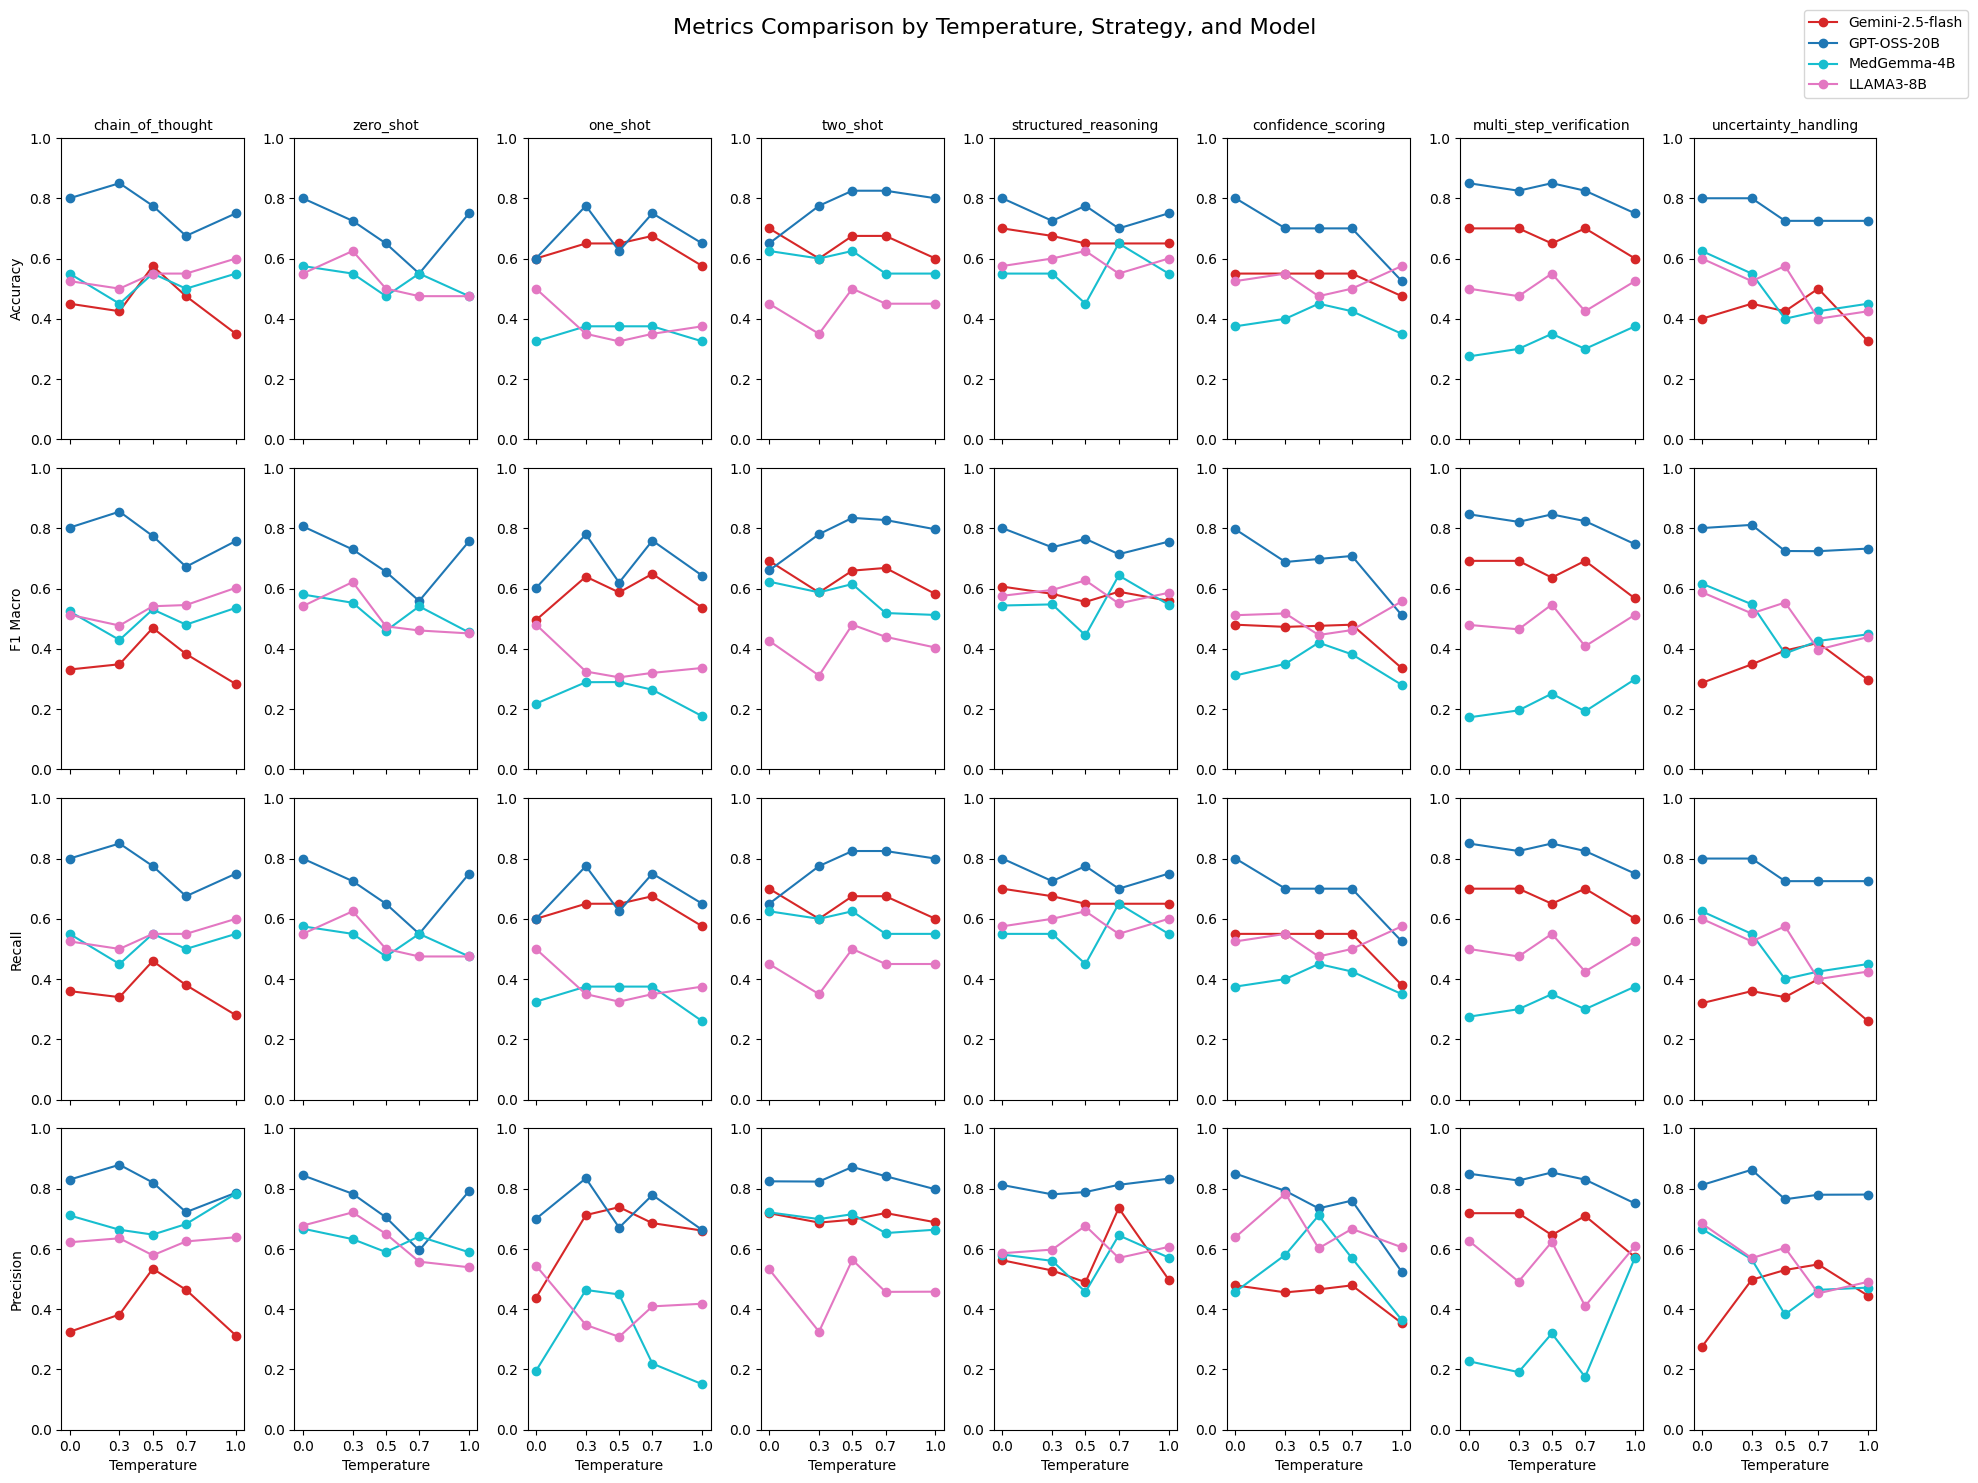

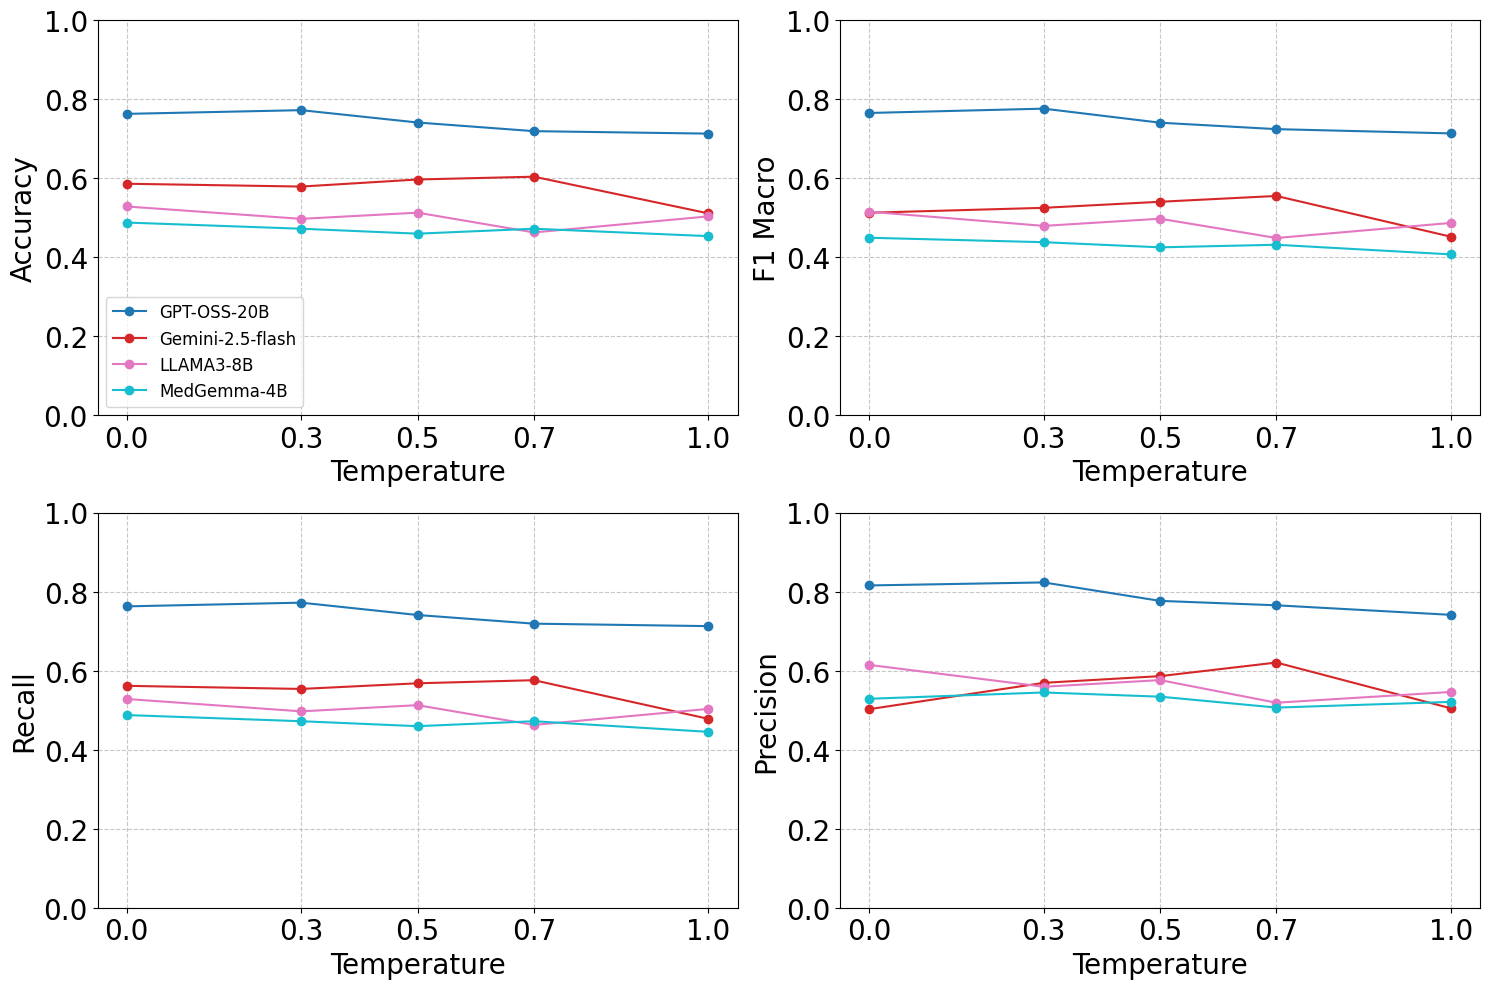

In [2]:
model_files = glob.glob('output/status_prompting_final/*/prediction/temperature_strategy_comparison.csv')
combined_df = plot_metrics_by_temperature(model_files)

In [3]:
# reorganize the combined_df for presentation
# Melt metrics into long format
df_long = combined_df.melt(id_vars=['strategy', 'temperature', 'model'],
                  value_vars=['accuracy', 'f1_macro', 'recall', 'precision'],
                  var_name='metric',
                  value_name='value')

# Pivot to get {model}_{metric} columns
df_wide = df_long.pivot_table(index=['strategy', 'temperature'],
                              columns=['model', 'metric'],
                              values='value').reset_index()

# Flatten MultiIndex columns
df_wide.columns = ['strategy', 'temperature'] + [f'{m}_{metric}' for m, metric in df_wide.columns[2:]]

df_wide

,strategy,temperature,GPT-OSS-20B_accuracy,GPT-OSS-20B_f1_macro,GPT-OSS-20B_precision,GPT-OSS-20B_recall,Gemini-2.5-flash_accuracy,Gemini-2.5-flash_f1_macro,Gemini-2.5-flash_precision,Gemini-2.5-flash_recall,LLAMA3-8B_accuracy,LLAMA3-8B_f1_macro,LLAMA3-8B_precision,LLAMA3-8B_recall,MedGemma-4B_accuracy,MedGemma-4B_f1_macro,MedGemma-4B_precision,MedGemma-4B_recall
0,chain_of_thought,0.0,0.800,0.802593,0.830159,0.800,0.450,0.331624,0.325000,0.360,0.525,0.513505,0.622222,0.525,0.550,0.524510,0.711310,0.550
1,chain_of_thought,0.3,0.850,0.855629,0.879464,0.850,0.425,0.349060,0.382308,0.340,0.500,0.477564,0.635417,0.500,0.450,0.429745,0.663690,0.450
2,chain_of_thought,0.5,0.775,0.774661,0.820536,0.775,0.575,0.469593,0.534359,0.460,0.550,0.541627,0.578968,0.550,0.550,0.531061,0.647642,0.550
3,chain_of_thought,0.7,0.675,0.672706,0.722222,0.675,0.475,0.383088,0.464444,0.380,0.550,0.545635,0.625000,0.550,0.500,0.480599,0.682639,0.500
4,chain_of_thought,1.0,0.750,0.758333,0.786607,0.750,0.350,0.283193,0.312698,0.280,0.600,0.602829,0.638889,0.600,0.550,0.536325,0.783654,0.550
5,confidence_scoring,0.0,0.800,0.796667,0.850000,0.800,0.550,0.480392,0.479167,0.550,0.525,0.511898,0.639493,0.525,0.375,0.311813,0.458333,0.375
6,confidence_scoring,0.3,0.700,0.688533,0.792647,0.700,0.550,0.473153,0.455918,0.550,0.550,0.517677,0.783654,0.550,0.400,0.350431,0.580645,0.400
7,confidence_scoring,0.5,0.700,0.698521,0.734776,0.700,0.550,0.476593,0.465839,0.550,0.475,0.446181,0.602273,0.475,0.450,0.420673,0.711207,0.450
8,confidence_scoring,0.7,0.700,0.708520,0.760504,0.700,0.550,0.480392,0.479167,0.550,0.500,0.462550,0.666558,0.500,0.425,0.382051,0.569540,0.425
9,confidence_scoring,1.0,0.525,0.511679,0.523810,0.525,0.475,0.335918,0.353623,0.380,0.575,0.557813,0.605556,0.575,0.350,0.280429,0.364247,0.350


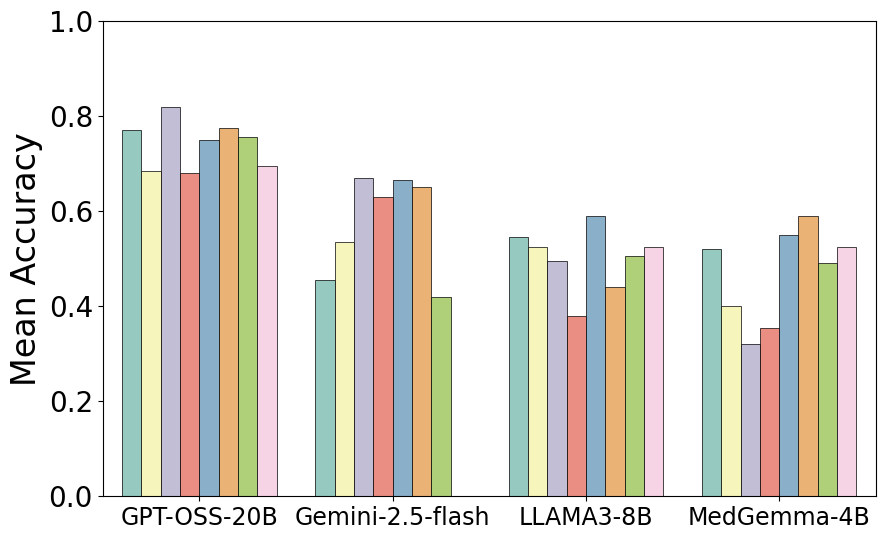

In [4]:
# GatorTron_acc = 0.97
# Average accuracy across all temperatures for each model-strategy pair
avg_df = (
    combined_df
    .groupby(['model', 'strategy'], as_index=False)['accuracy']
    .mean()
)
# Set up the plot
plt.figure(figsize=(9, 5.5))

ax = sns.barplot(
    data=avg_df,
    x='model',
    y='accuracy',
    hue='strategy',
    palette='Set3',
    edgecolor='black',
    linewidth=0.5
)
# ax.axhline(GatorTron_acc, color='gray', linestyle='--', label='GatorTron Accuracy = {}'.format(GatorTron_acc))

# Formatting
ax.set_ylabel('Mean Accuracy', fontsize=24)
ax.set_xlabel('')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', labelsize=17)
ax.tick_params(axis='y', labelsize=20)

plt.legend(
    title='Strategy',
    fontsize=12,
    title_fontsize=13,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)

plt.legend().set_visible(False)
plt.tight_layout()
# Save with 
plt.show()

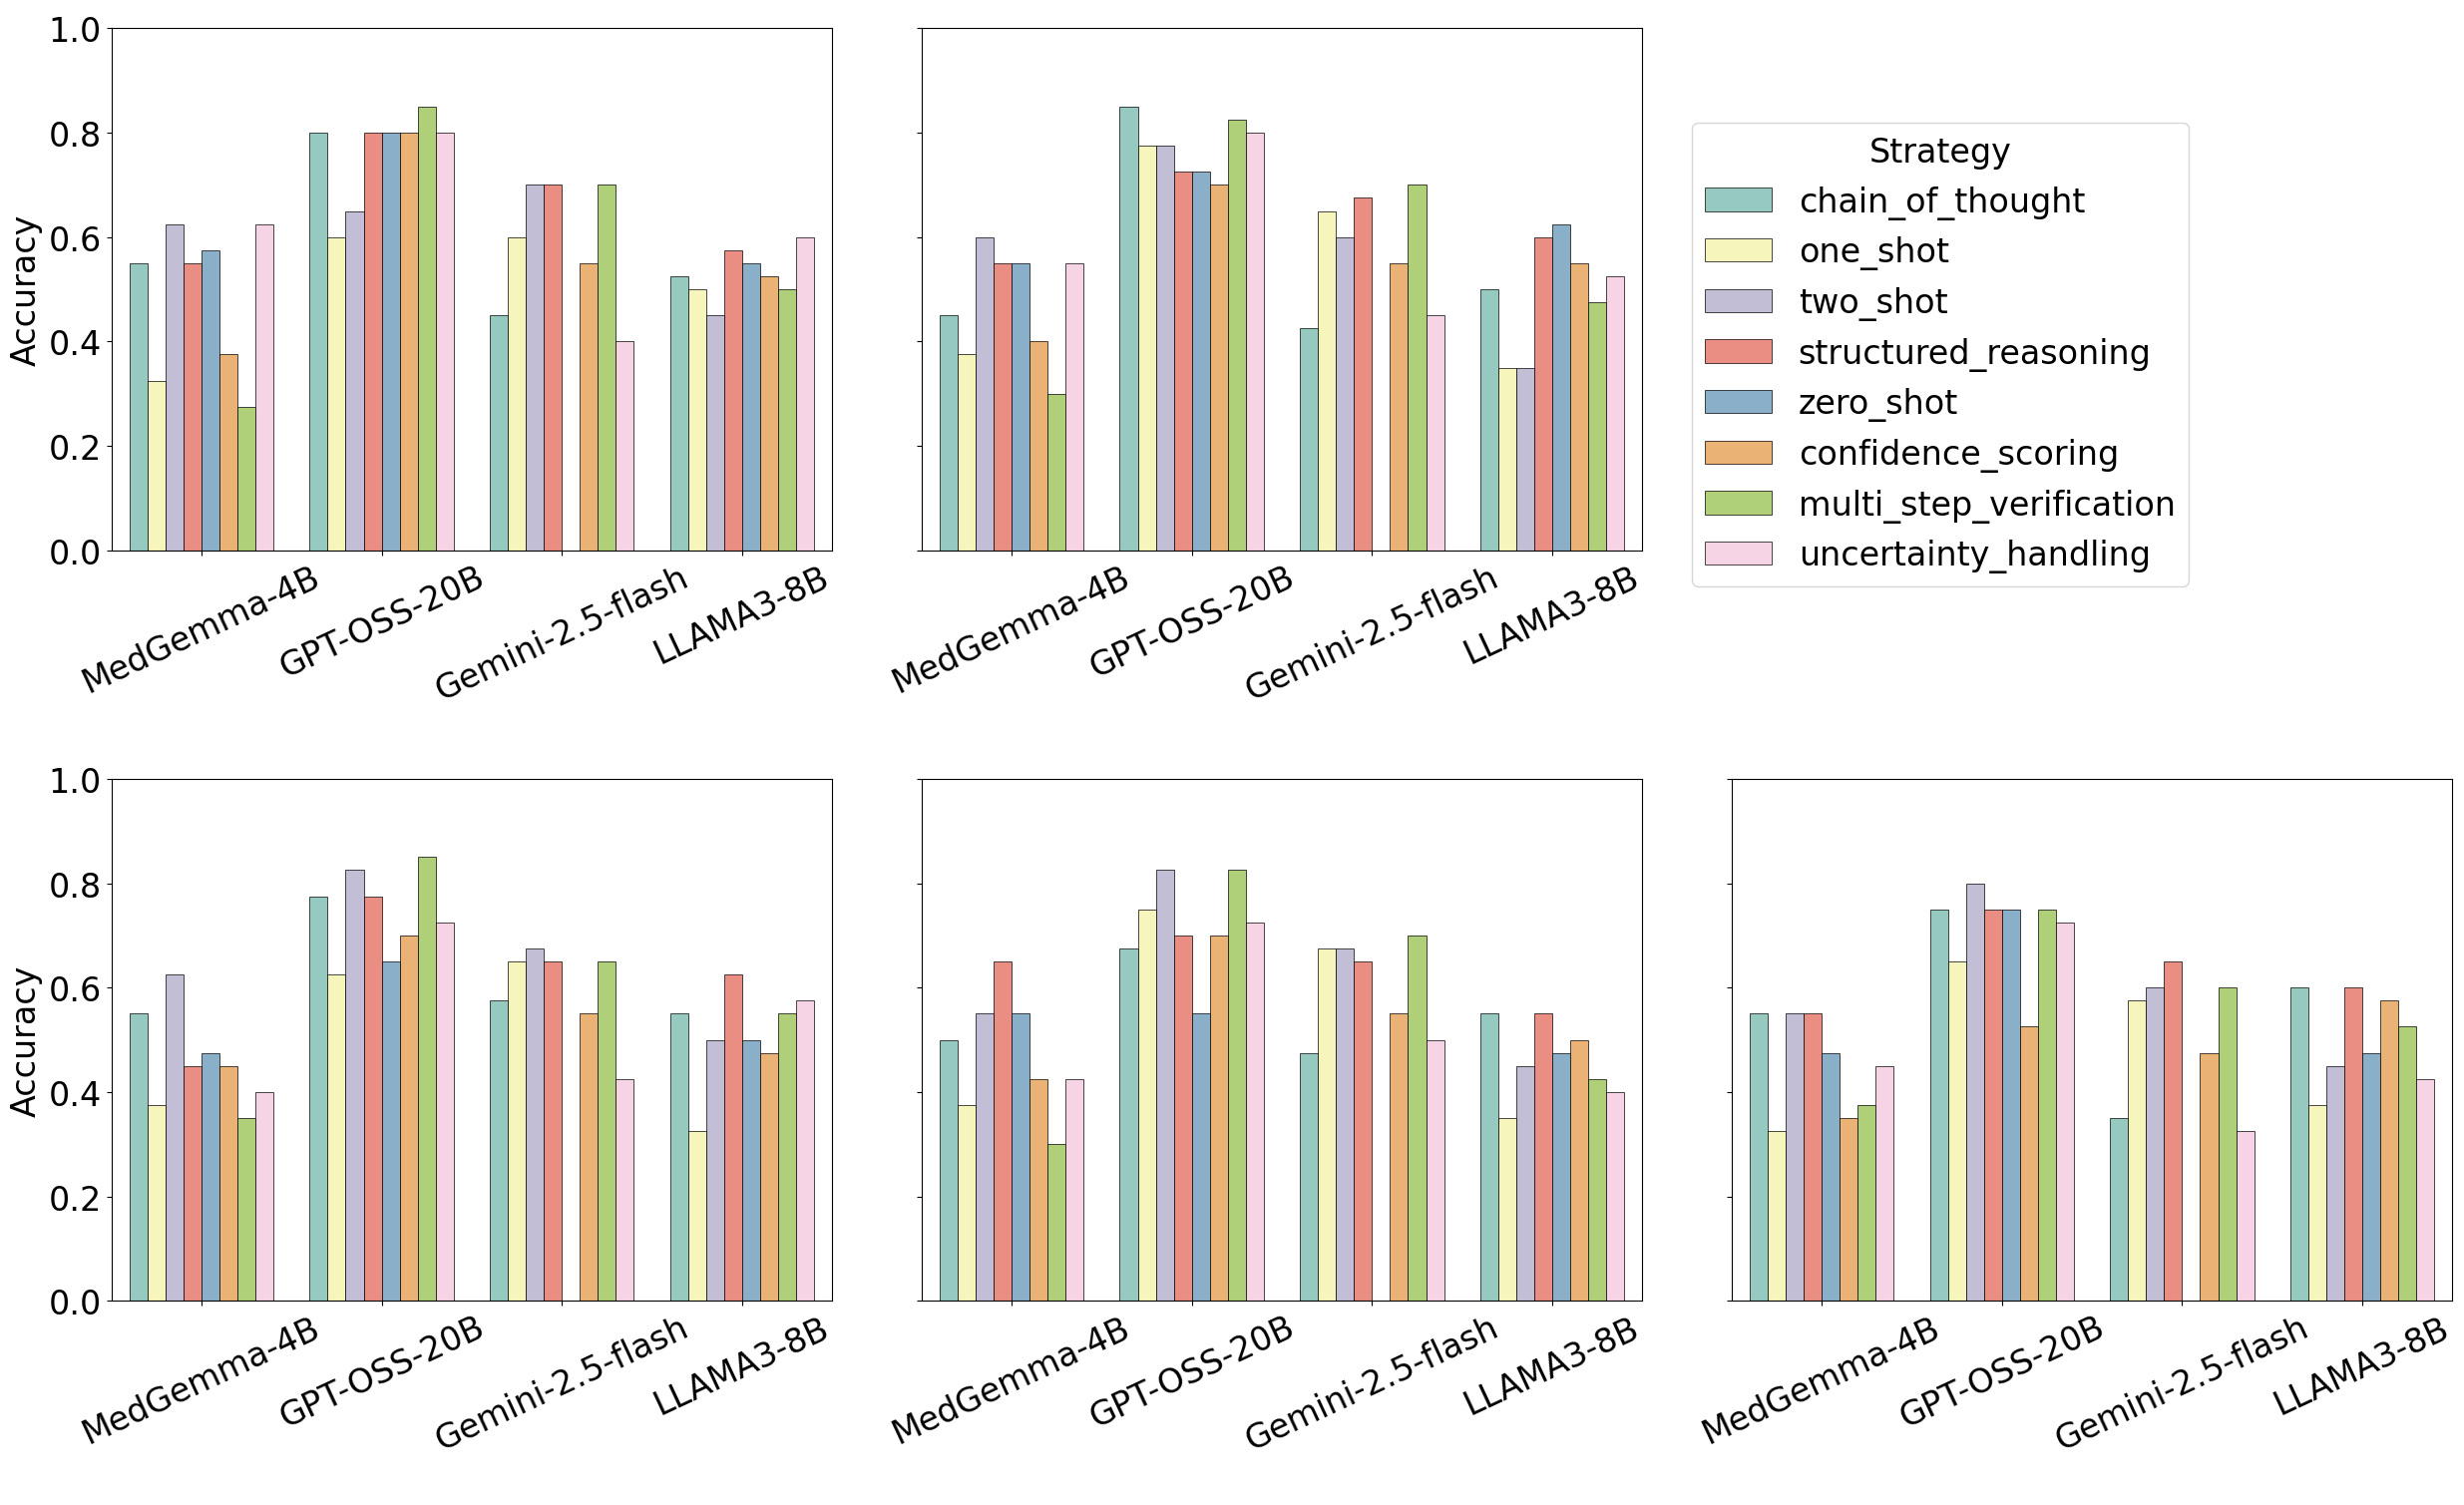

In [5]:
# Set up the plot
fig, axes = plt.subplots(2, 3, figsize=(25, 16), sharey=True)

# Unique temperatures
temperatures = sorted(combined_df['temperature'].unique())

plot_idx = 0
legend_handles, legend_labels = None, None

# Plot for each temperature
for temp in temperatures:
    # Skip top-right subplot (row 0, col 2)
    while plot_idx == 2:
        plot_idx += 1

    ax = axes[plot_idx // 3, plot_idx % 3]
    subset = combined_df[combined_df['temperature'] == temp]

    sns.barplot(
        data=subset,
        x='model',
        y='accuracy',
        hue='strategy',
        ax=ax,
        palette='Set3',
        edgecolor='black',
        linewidth=0.5
    )
    # add horizontal line for GatorTron accuracy
    # ax.axhline(GatorTron_acc, color='gray', linestyle='--', label='GatorTron')
    ax.set_title(f' ', fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Accuracy' if plot_idx in [0, 3] else '', fontsize=24)
    ax.set_xlabel(' ', fontsize=24)
    ax.tick_params(axis='x', labelsize=24, rotation=25)
    ax.tick_params(axis='y', labelsize=24)

    # Save legend info from the first plotted axis
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # Remove legend from individual subplots
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    plot_idx += 1

# Remove the top-right axis
fig.delaxes(axes[0, 2])

# Add legend in the empty top-right area
fig.legend(
    legend_handles,
    legend_labels,
    title='Strategy',
    loc='upper center',
    bbox_to_anchor=(0.78, 0.88),  # adjust to fine-tune position
    ncol=1,
    fontsize=24,
    title_fontsize=24,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

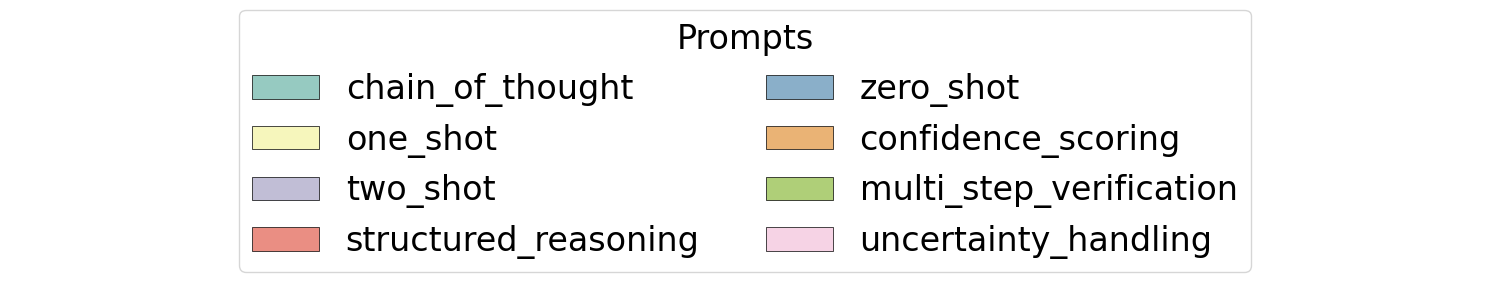

In [6]:
# generate a separate legend for manuscript, using one row format with larger font size
plt.figure(figsize=(15, 2))
plt.legend(
    legend_handles,
    legend_labels,
    title='Prompts',
    loc='center',
    ncol=2,  # adjust to fit all strategies in one row
    fontsize=24,
    title_fontsize=24,
    frameon=True
)
plt.axis('off')  # Hide axes
plt.tight_layout()
plt.show()

gpt-oss-20b/prediction/chain_of_thought_temp0.3_predictions.json


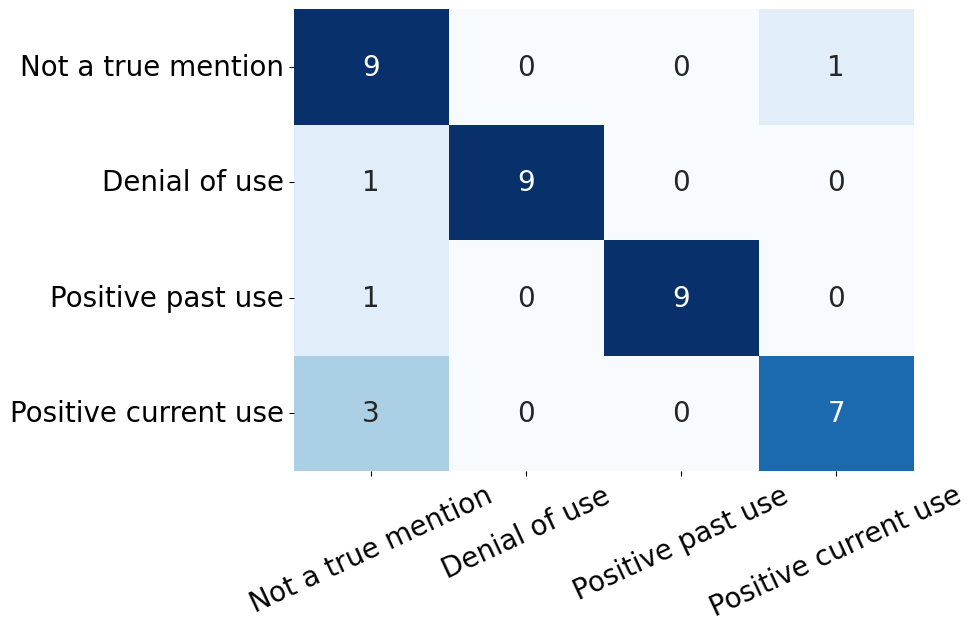

In [7]:
# grab the best model of all the comparisons, and plot the confusion matrix

best_model_row = combined_df.sort_values(by='accuracy', ascending=False).iloc[0]
best_model_name = best_model_row['model']
best_model_id = best_model_row['model_id']
best_model_temperature = best_model_row['temperature']
best_model_prompting_strategy = best_model_row['strategy']

best_model_combo = f"{best_model_id}/prediction/{best_model_prompting_strategy}_temp{best_model_temperature}_predictions.json"
print(best_model_combo)
# load y_true and y_pred for the best model
with open(os.path.join('output/status_prompting_final', best_model_combo), 'r') as f:
    predictions = json.load(f)
y_true = np.array([item['true_label'] for item in predictions])
y_pred = np.array([item['predicted_label'] for item in predictions])
cm = confusion_matrix(y_true, y_pred, labels=[1,2,3,4])

# make cm plot

labels=["Not a true mention", "Denial of use", "Positive past use", "Positive current use"]
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels, annot_kws={'fontsize':20})
plt.xticks(rotation=25, fontsize=20)
plt.yticks(rotation=0, fontsize=20)
plt.show()

### GatorTron confusion matrix (status)

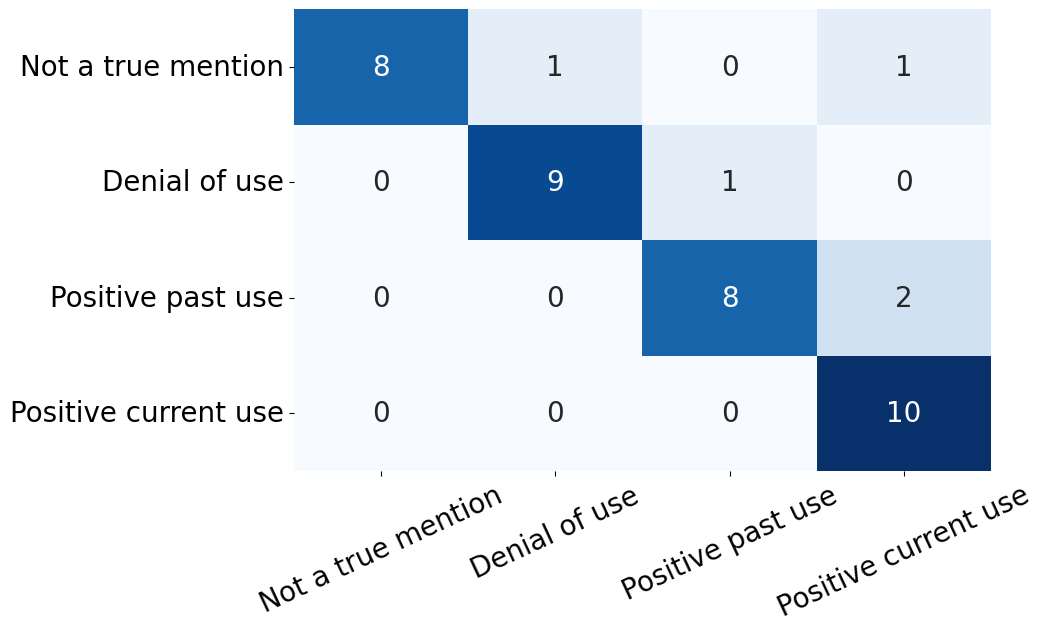

In [8]:
# get the GatorTron:
# grab the best model of all the comparisons, and plot the confusion matrix

y_true = np.load('output/gatortron-base_finetune_status/y_test_best.npy')
y_pred = np.load('output/gatortron-base_finetune_status/y_pred_best.npy')
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3])

# make cm plot
labels=["Not a true mention", "Denial of use", "Positive past use", "Positive current use"]
plt.figure(figsize=(9, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, annot_kws={'fontsize':20}, cbar=False)
plt.xticks(rotation=25, fontsize=20)
plt.yticks(rotation=0, fontsize=20)
plt.show()

## 2. Reason Figures

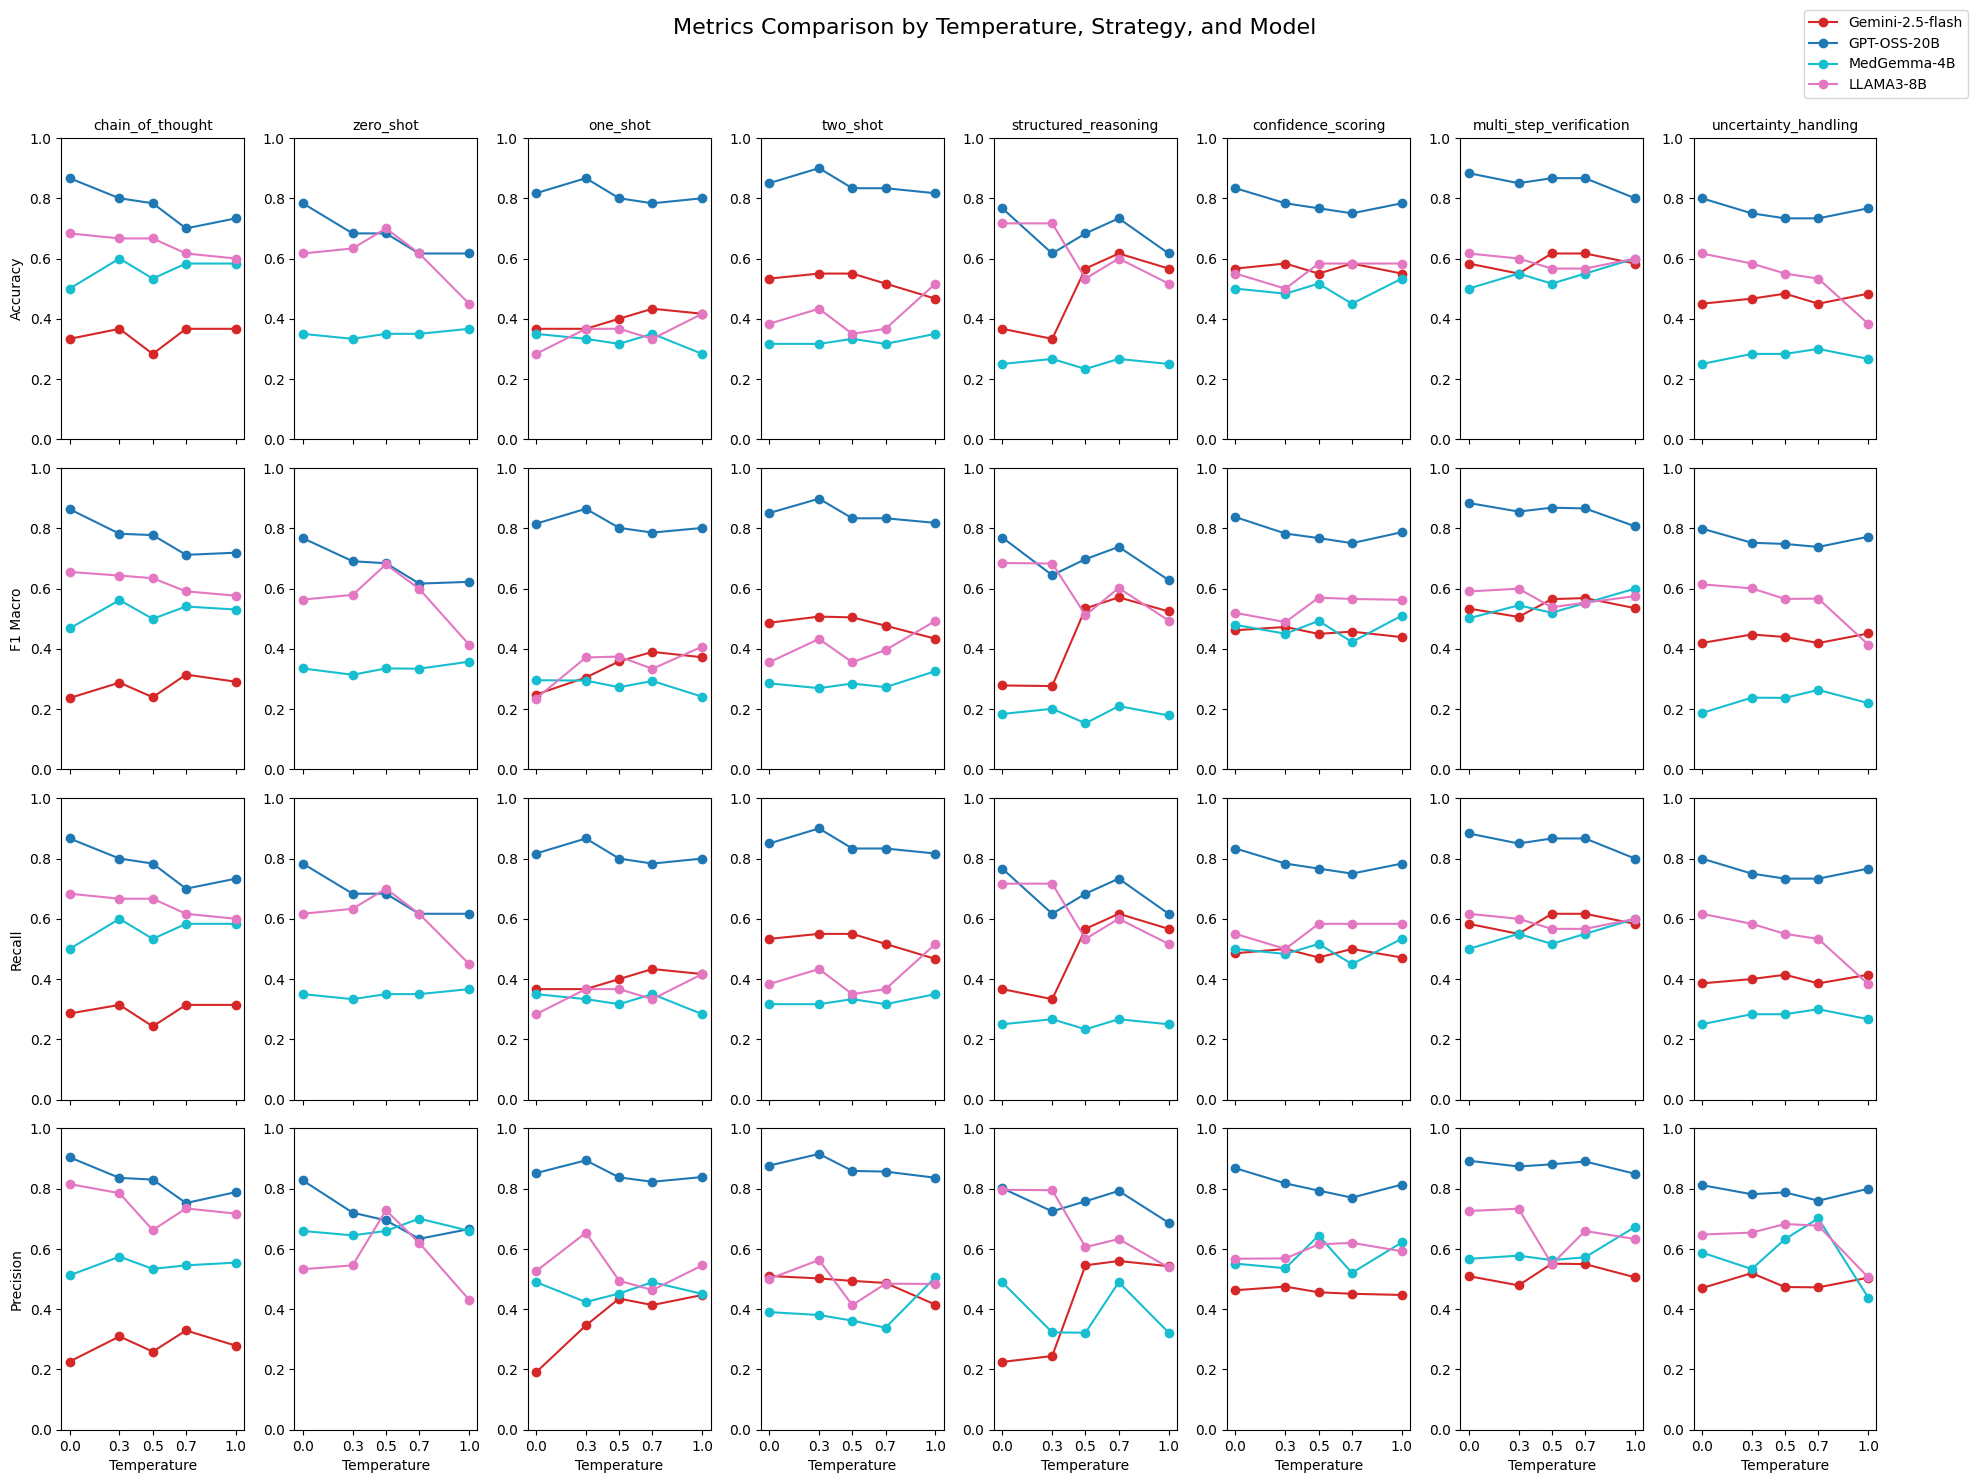

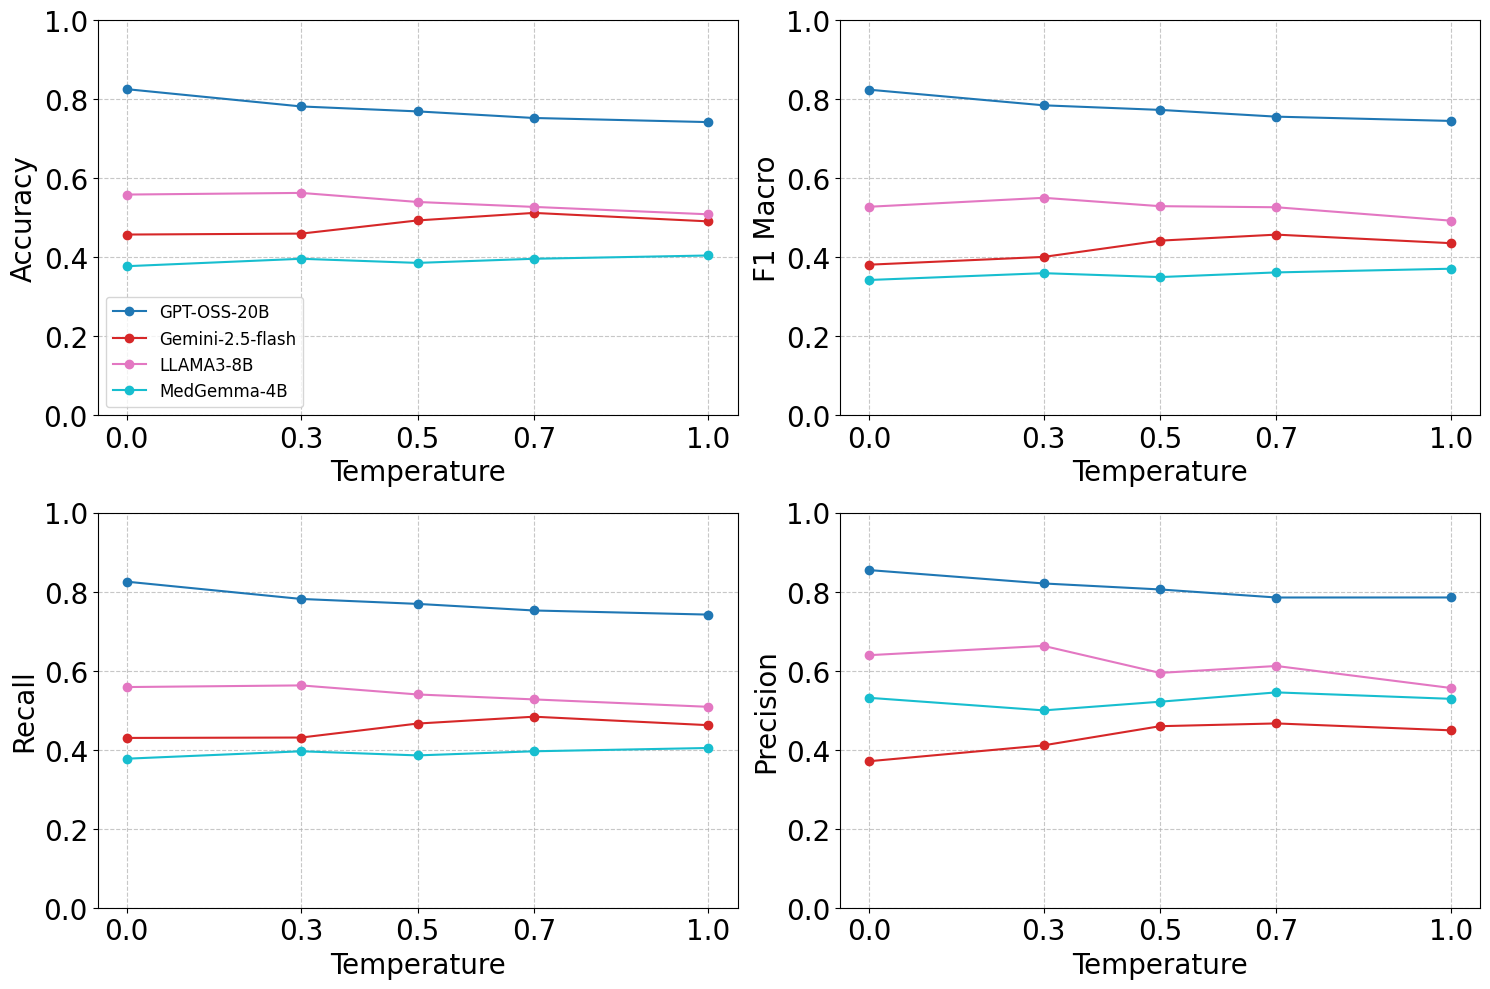

In [9]:
model_files = glob.glob('output/reason_prompting_final/*/prediction/temperature_strategy_comparison.csv')
combined_df = plot_metrics_by_temperature(model_files)

In [10]:
# reorganize the combined_df for presentation
# Melt metrics into long format
df_long = combined_df.melt(id_vars=['strategy', 'temperature', 'model'],
                  value_vars=['accuracy', 'f1_macro', 'recall', 'precision'],
                  var_name='metric',
                  value_name='value')

# Pivot to get {model}_{metric} columns
df_wide = df_long.pivot_table(index=['strategy', 'temperature'],
                              columns=['model', 'metric'],
                              values='value').reset_index()

# Flatten MultiIndex columns
df_wide.columns = ['strategy', 'temperature'] + [f'{m}_{metric}' for m, metric in df_wide.columns[2:]]

df_wide

,strategy,temperature,GPT-OSS-20B_accuracy,GPT-OSS-20B_f1_macro,GPT-OSS-20B_precision,GPT-OSS-20B_recall,Gemini-2.5-flash_accuracy,Gemini-2.5-flash_f1_macro,Gemini-2.5-flash_precision,Gemini-2.5-flash_recall,LLAMA3-8B_accuracy,LLAMA3-8B_f1_macro,LLAMA3-8B_precision,LLAMA3-8B_recall,MedGemma-4B_accuracy,MedGemma-4B_f1_macro,MedGemma-4B_precision,MedGemma-4B_recall
0,chain_of_thought,0.0,0.866667,0.863878,0.904167,0.866667,0.333333,0.236992,0.226190,0.285714,0.683333,0.655631,0.815441,0.683333,0.500000,0.468045,0.512458,0.500000
1,chain_of_thought,0.3,0.800000,0.782259,0.835897,0.800000,0.366667,0.288077,0.309740,0.314286,0.666667,0.643432,0.785104,0.666667,0.600000,0.561944,0.574495,0.600000
2,chain_of_thought,0.5,0.783333,0.777789,0.830320,0.783333,0.283333,0.239683,0.259184,0.242857,0.666667,0.634708,0.662698,0.666667,0.533333,0.499824,0.533883,0.533333
3,chain_of_thought,0.7,0.700000,0.712257,0.752340,0.700000,0.366667,0.314781,0.329474,0.314286,0.616667,0.591083,0.734506,0.616667,0.583333,0.540806,0.545570,0.583333
4,chain_of_thought,1.0,0.733333,0.719361,0.788817,0.733333,0.366667,0.291066,0.278896,0.314286,0.600000,0.576721,0.717328,0.600000,0.583333,0.530632,0.554684,0.583333
5,confidence_scoring,0.0,0.833333,0.837553,0.867949,0.833333,0.566667,0.461928,0.463004,0.485714,0.550000,0.519604,0.567460,0.550000,0.500000,0.479666,0.551275,0.500000
6,confidence_scoring,0.3,0.783333,0.782988,0.817631,0.783333,0.583333,0.472826,0.475013,0.500000,0.500000,0.488912,0.568700,0.500000,0.483333,0.450513,0.536111,0.483333
7,confidence_scoring,0.5,0.766667,0.767854,0.793697,0.766667,0.550000,0.449865,0.456227,0.471429,0.583333,0.570238,0.615152,0.583333,0.516667,0.492943,0.644511,0.516667
8,confidence_scoring,0.7,0.750000,0.751002,0.770437,0.750000,0.583333,0.457381,0.451247,0.500000,0.583333,0.565746,0.620352,0.583333,0.450000,0.423016,0.520635,0.450000
9,confidence_scoring,1.0,0.783333,0.787435,0.813649,0.783333,0.550000,0.439048,0.447279,0.471429,0.583333,0.563059,0.592460,0.583333,0.533333,0.510418,0.621693,0.533333


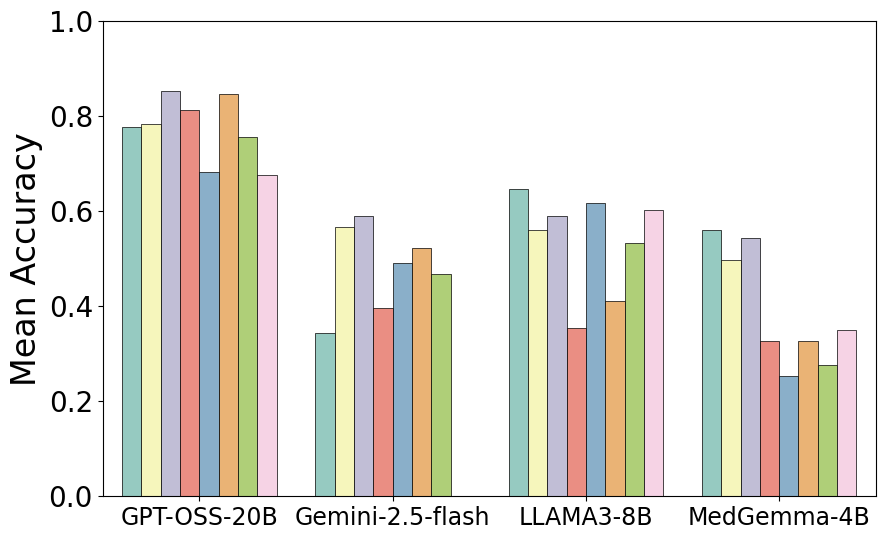

In [11]:
# Average accuracy across all temperatures for each model-strategy pair
avg_df = (
    combined_df
    .groupby(['model', 'strategy'], as_index=False)['accuracy']
    .mean()
)

# Set up the plot
plt.figure(figsize=(9, 5.5))

ax = sns.barplot(
    data=avg_df,
    x='model',
    y='accuracy',
    hue='strategy',
    palette='Set3',
    edgecolor='black',
    linewidth=0.5
)

# Formatting
ax.set_ylabel('Mean Accuracy', fontsize=24)
ax.set_xlabel('')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', labelsize=17)
ax.tick_params(axis='y', labelsize=20)

plt.legend(
    title='Strategy',
    fontsize=12,
    title_fontsize=13,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)

plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

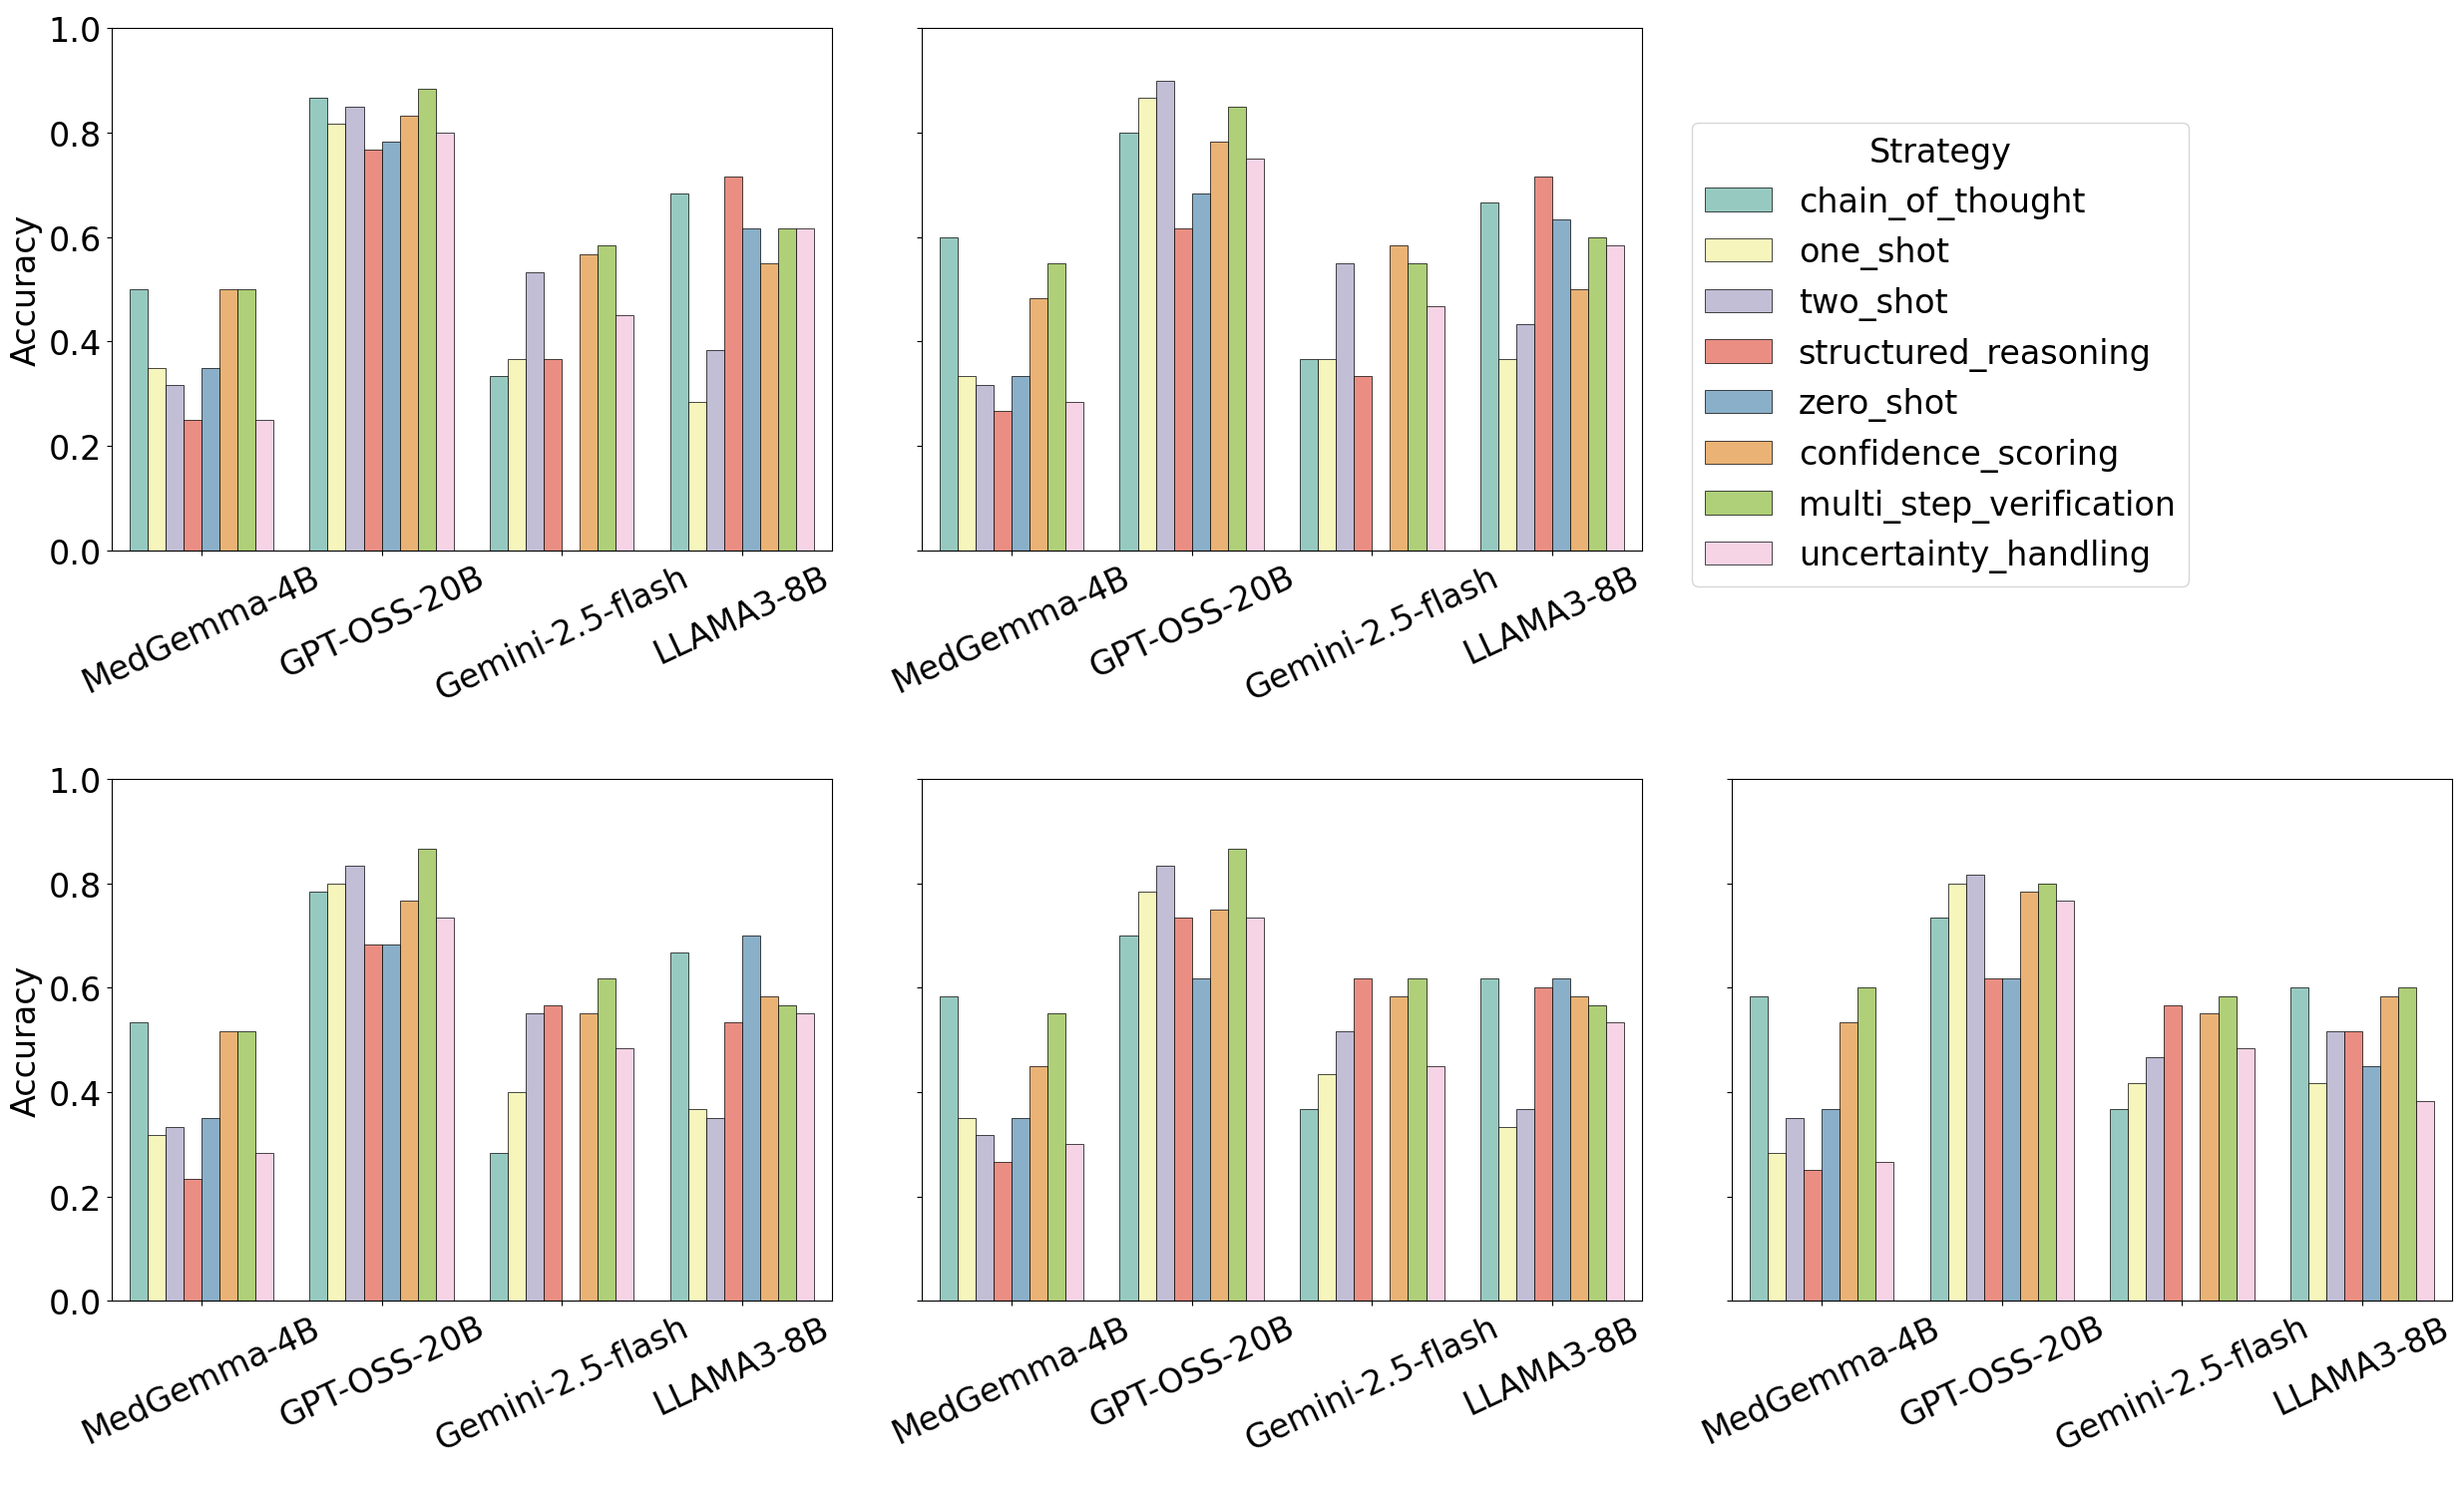

In [12]:
# Set up the plot
fig, axes = plt.subplots(2, 3, figsize=(25, 16), sharey=True)

# Unique temperatures
temperatures = sorted(combined_df['temperature'].unique())

plot_idx = 0
legend_handles, legend_labels = None, None

# Plot for each temperature
for temp in temperatures:
    # Skip top-right subplot (row 0, col 2)
    while plot_idx == 2:
        plot_idx += 1

    ax = axes[plot_idx // 3, plot_idx % 3]
    subset = combined_df[combined_df['temperature'] == temp]

    sns.barplot(
        data=subset,
        x='model',
        y='accuracy',
        hue='strategy',
        ax=ax,
        palette='Set3',
        edgecolor='black',
        linewidth=0.5
    )
    
    ax.set_title(f' ', fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Accuracy' if plot_idx in [0, 3] else '', fontsize=24)
    ax.set_xlabel(' ', fontsize=24)
    ax.tick_params(axis='x', labelsize=24, rotation=25)
    ax.tick_params(axis='y', labelsize=24)

    # Save legend info from the first plotted axis
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # Remove legend from individual subplots
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    plot_idx += 1

# Remove the top-right axis
fig.delaxes(axes[0, 2])

# Add legend in the empty top-right area
fig.legend(
    legend_handles,
    legend_labels,
    title='Strategy',
    loc='upper center',
    bbox_to_anchor=(0.78, 0.88),  # adjust to fine-tune position
    ncol=1,
    fontsize=24,
    title_fontsize=24,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

gpt-oss-20b/prediction/two_shot_temp0.3_predictions.json


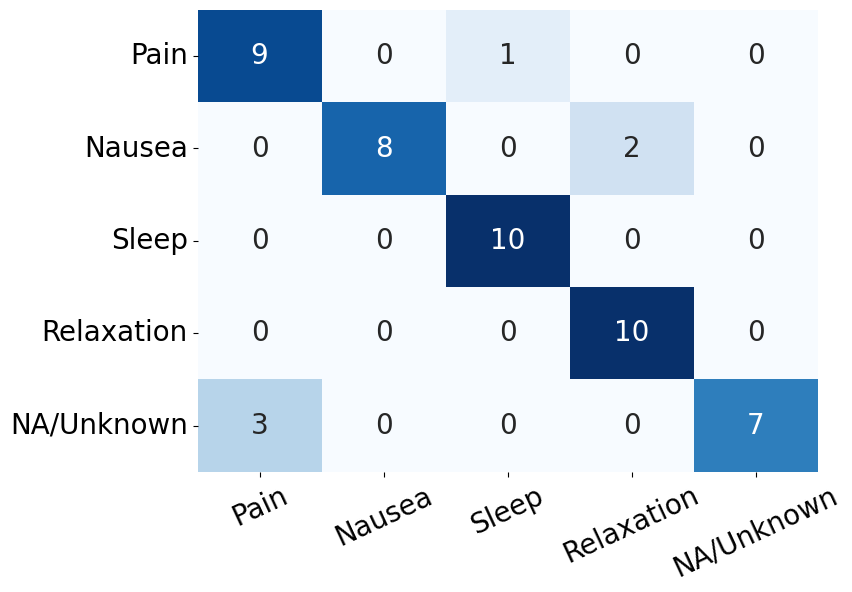

In [13]:
# grab the best model of all the comparisons, and plot the confusion matrix

best_model_row = combined_df.sort_values(by='accuracy', ascending=False).iloc[0]
best_model_name = best_model_row['model']
best_model_id = best_model_row['model_id']
best_model_temperature = best_model_row['temperature']
best_model_prompting_strategy = best_model_row['strategy']

best_model_combo = f"{best_model_id}/prediction/{best_model_prompting_strategy}_temp{best_model_temperature}_predictions.json"
# load y_true and y_pred for the best model
print(best_model_combo)
with open(os.path.join('output/reason_prompting_final', best_model_combo), 'r') as f:
    predictions = json.load(f)
y_true = np.array([item['true_label'] for item in predictions])
y_pred = np.array([item['predicted_label'] for item in predictions])

# remove the "Appetite" label fromthe predictions
y_true = y_true[y_true != 5]
y_pred = y_pred[y_pred != 5]

cm = confusion_matrix(y_true, y_pred, labels=[1,2,3,4,6])

# make cm plot
labels=["Pain", "Nausea", "Sleep", "Relaxation",  "NA/Unknown"]
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels, annot_kws={'fontsize':20})
plt.xticks(rotation=25, fontsize=20)
plt.yticks(rotation=0, fontsize=20)
plt.show()

In [14]:
# print the per class classification report
print(classification_report(y_true, y_pred, target_names=labels, digits=3))

              precision    recall  f1-score   support

        Pain      0.750     0.900     0.818        10
      Nausea      1.000     0.800     0.889        10
       Sleep      0.909     1.000     0.952        10
  Relaxation      0.833     1.000     0.909        10
  NA/Unknown      1.000     0.700     0.824        10

    accuracy                          0.880        50
   macro avg      0.898     0.880     0.878        50
weighted avg      0.898     0.880     0.878        50



## 3. Bootstrapping for confidence intervals

In [15]:
def load_predictions_from_json(json_path):
    """
    Load prediction results from a JSON file.

    Expected format:
    [
      {
        "snippet": "...",
        "true_label": 1,
        "predicted_label": 1,
        "full_response": "..."
      },
      ...
    ]
    """
    with open(json_path, "r", encoding="utf-8") as f:
        records = json.load(f)

    df = pd.DataFrame(records)

    required_cols = ["true_label", "predicted_label"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in JSON: {missing}")

    return df

def load_predictions_from_csv(csv_path):
    """
    Load prediction results from a CSV file.

    Expected format:
    true_label,predicted_label,full_response
    1,1,"..."
    2,3,"..."
    ...
    """
    df = pd.read_csv(csv_path)

    # check for required columns
    required_cols = ["y_true", "y_pred"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in CSV: {missing}")
    # rename y_true to true_label and  y_pred to predicted_label for consistency
    df = df.rename(columns={"y_true": "true_label", "y_pred": "predicted_label"})
    return df

def compute_metrics(y_true, y_pred):

    """
    Compute classification metrics.
    """
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
    }

def summarize_bootstrap(metric_values, observed_value):
    """
    Summarize bootstrap distribution for one metric.
    """
    ci_lower, ci_upper = np.percentile(metric_values, [2.5, 97.5])

    return {
        "observed": float(observed_value),
        "bootstrap_mean": float(np.mean(metric_values)),
        "bootstrap_median": float(np.median(metric_values)),
        "ci_lower_95": float(ci_lower),
        "ci_upper_95": float(ci_upper),
        "prop_bootstrap_ge_observed": float(np.mean(metric_values >= observed_value)),
    }

def stratified_bootstrap_metrics(
    df,
    n_bootstrap=10000,
    seed=42,
    true_label_col="true_label",
    pred_label_col="predicted_label"
):
    """
    Stratified bootstrap with replacement.

    For each bootstrap replicate:
      - sample WITH replacement within each true class
      - preserve the original number of examples per class
      - compute accuracy, f1_macro, recall_macro, precision_macro

    Assumes df contains one row per fixed test example with:
      - true_label
      - predicted_label
    """
    rng = np.random.default_rng(seed)

    if true_label_col not in df.columns or pred_label_col not in df.columns:
        raise ValueError(
            f"DataFrame must contain '{true_label_col}' and '{pred_label_col}'."
        )

    df = df.copy().reset_index(drop=True)
    df[true_label_col] = df[true_label_col].astype(int)
    df[pred_label_col] = df[pred_label_col].astype(int)

    y_true_obs = df[true_label_col].to_numpy()
    y_pred_obs = df[pred_label_col].to_numpy()

    observed_metrics = compute_metrics(y_true_obs, y_pred_obs)

    class_counts = df[true_label_col].value_counts().sort_index()
    classes = class_counts.index.tolist()

    class_indices = {
        cls: df.index[df[true_label_col] == cls].to_numpy()
        for cls in classes
    }

    bootstrap_results = {
        "accuracy": np.empty(n_bootstrap, dtype=float),
        "f1_macro": np.empty(n_bootstrap, dtype=float),
        "recall_macro": np.empty(n_bootstrap, dtype=float),
        "precision_macro": np.empty(n_bootstrap, dtype=float),
    }

    for b in range(n_bootstrap):
        sampled_indices = []

        for cls in classes:
            idx_cls = class_indices[cls]
            n_cls = len(idx_cls)
            sampled_cls = rng.choice(idx_cls, size=n_cls, replace=True)
            sampled_indices.append(sampled_cls)

        sampled_indices = np.concatenate(sampled_indices)

        y_true_b = df.loc[sampled_indices, true_label_col].to_numpy()
        y_pred_b = df.loc[sampled_indices, pred_label_col].to_numpy()

        metrics_b = compute_metrics(y_true_b, y_pred_b)

        for metric_name, metric_value in metrics_b.items():
            bootstrap_results[metric_name][b] = metric_value

    summary = {
        "n_bootstrap": int(n_bootstrap),
        "n_test": int(len(df)),
        "class_counts": class_counts.to_dict(),
    }

    for metric_name in bootstrap_results:
        metric_summary = summarize_bootstrap(
            bootstrap_results[metric_name],
            observed_metrics[metric_name]
        )
        for k, v in metric_summary.items():
            summary[f"{metric_name}_{k}"] = v

    return summary, bootstrap_results

def wilson_ci(k, n, z=1.959963984540054):
    """
    Wilson score interval for a binomial proportion.
    Mainly appropriate for accuracy on a fixed test set.
    """
    if n == 0:
        raise ValueError("n must be > 0")

    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half_width = (
        z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))
    ) / denom

    return center - half_width, center + half_width

def bootstrap_for_ci(
    prediction_path,
    n_bootstrap=10000,
    seed=42,
    save_bootstrap_distribution_prefix=None
):
    """
    Full pipeline:
      1. Load fixed prediction results from JSON
      2. Compute observed metrics
      3. Run stratified bootstrap CI
      4. Compute Wilson CI for accuracy
      5. Optionally save bootstrap distributions
    """
    if not os.path.exists(prediction_path):
        raise FileNotFoundError(f"Prediction file not found: {prediction_path}")
    # if path ends with .csv, load from csv, else load from json
    if prediction_path.endswith('.csv'):
        df = load_predictions_from_csv(prediction_path)
    else:
        df = load_predictions_from_json(prediction_path)

    summary, bootstrap_results = stratified_bootstrap_metrics(
        df=df,
        n_bootstrap=n_bootstrap,
        seed=seed,
        true_label_col="true_label",
        pred_label_col="predicted_label"
    )

    n_correct = int((df["true_label"] == df["predicted_label"]).sum())
    n_total = len(df)
    wilson_lower, wilson_upper = wilson_ci(n_correct, n_total)

    summary["n_correct"] = n_correct
    summary["accuracy_wilson_ci_lower_95"] = float(wilson_lower)
    summary["accuracy_wilson_ci_upper_95"] = float(wilson_upper)

    if save_bootstrap_distribution_prefix is not None:
        for metric_name, values in bootstrap_results.items():
            out_path = f"{save_bootstrap_distribution_prefix}_{metric_name}.csv"
            pd.DataFrame({metric_name: values}).to_csv(out_path, index=False)

    return df, summary, bootstrap_results

def get_the_best_strategy(model_id, task="status"):
    path = f"output/{task}_prompting_final/{model_id}/prediction/temperature_strategy_comparison.csv"
    perf_df = pd.read_csv(path)
    # get the best performing strategy and temperature with the highest accuracy:
    # if there are multiple rows with the same accuracy, then compare f1_macro
    best_row = perf_df.sort_values(by=['accuracy', 'f1_macro'], ascending=False).iloc[0]
    temperature = best_row['temperature']
    strategy = best_row['strategy']

    return temperature, strategy

### Status classification

In [ ]:
model_id = "gpt-oss-20b"
temperature, strategy = get_the_best_strategy(model_id)
print(f"Best strategy: {strategy} with temperature {temperature}")
json_path = f"output/status_prompting_final/{model_id}/prediction/{strategy}_temp{temperature}_predictions.json"

df, summary, bootstrap_results = bootstrap_for_ci(
    prediction_path=json_path,
    n_bootstrap=10000,
    seed=42,
    save_bootstrap_distribution_prefix=f"output/status_prompting_final/{model_id}/bootstrap/{strategy}_temp{temperature}_bootstrap"
)

print("Bootstrap summary:")
for k, v in summary.items():
    print(f"{k}: {v}")

In [ ]:
model_id = "Llama-3.1-8B"
temperature, strategy = get_the_best_strategy(model_id, task="status")
print(f"Best strategy: {strategy} with temperature {temperature}")
json_path = f"output/status_prompting_final/{model_id}/prediction/{strategy}_temp{temperature}_predictions.json"

df, summary, bootstrap_accuracies = bootstrap_for_ci(
    prediction_path=json_path,
    n_bootstrap=10000,
    seed=42,
    save_bootstrap_distribution_prefix=f"output/status_prompting_final/{model_id}/bootstrap/{strategy}_temp{temperature}_bootstrap_distribution"
)

print("Bootstrap summary:")
for k, v in summary.items():
    print(f"{k}: {v}")

In [ ]:
model_id = "medgemma-4b"
temperature, strategy = get_the_best_strategy(model_id, task="status")
print(f"Best strategy: {strategy} with temperature {temperature}")
json_path = f"output/status_prompting_final/{model_id}/prediction/{strategy}_temp{temperature}_predictions.json"

df, summary, bootstrap_accuracies = bootstrap_for_ci(
    prediction_path=json_path,
    n_bootstrap=10000,
    seed=42,
    save_bootstrap_distribution_prefix=f"output/status_prompting_final/{model_id}/bootstrap/{strategy}_temp{temperature}_bootstrap_distribution"
)

print("Bootstrap summary:")
for k, v in summary.items():
    print(f"{k}: {v}")

In [ ]:
model_id = "gemini-2.0-flash"
temperature, strategy = get_the_best_strategy(model_id)
print(f"Best strategy: {strategy} with temperature {temperature}")
prediction_path = f"output/status_prompting_final/{model_id}/prediction/output_status_prompting_test_gemini-2.0-flash-lite-001_prediction_{strategy}_temp{temperature}_predictions.csv"
# make bootstrap directory

df, summary, bootstrap_accuracies = bootstrap_for_ci(
    prediction_path=prediction_path,
    n_bootstrap=10000,
    seed=42,
    save_bootstrap_distribution_prefix=f"output/status_prompting_final/{model_id}/bootstrap/{strategy}_temp{temperature}_bootstrap_distribution"
)

print("Bootstrap summary:")
for k, v in summary.items():
    print(f"{k}: {v}")

### Reason classification

In [ ]:
task = "reason"
model_id = "gpt-oss-20b"
temperature, strategy = get_the_best_strategy(model_id, task=task)
print(f"Best strategy: {strategy} with temperature {temperature}")
json_path = f"output/{task}_prompting_final/{model_id}/prediction/{strategy}_temp{temperature}_predictions.json"

df, summary, bootstrap_accuracies = bootstrap_for_ci(
    prediction_path=json_path,
    n_bootstrap=10000,
    seed=42,
    save_bootstrap_distribution_prefix=f"output/{task}_prompting_final/{model_id}/bootstrap/{strategy}_temp{temperature}_bootstrap_distribution"
)

print("Bootstrap summary:")
for k, v in summary.items():
    print(f"{k}: {v}")

In [ ]:
task = "reason"
model_id = "medgemma-4b"
temperature, strategy = get_the_best_strategy(model_id, task=task)
print(f"Best strategy: {strategy} with temperature {temperature}")
json_path = f"output/{task}_prompting_final/{model_id}/prediction/{strategy}_temp{temperature}_predictions.json"

df, summary, bootstrap_accuracies = bootstrap_for_ci(
    prediction_path=json_path,
    n_bootstrap=10000,
    seed=42,
    save_bootstrap_distribution_prefix=f"output/{task}_prompting_final/{model_id}/bootstrap/{strategy}_temp{temperature}_bootstrap_distribution"
)

print("Bootstrap summary:")
for k, v in summary.items():
    print(f"{k}: {v}")

In [ ]:
task = "reason"
model_id = "Llama-3.1-8B"
temperature, strategy = get_the_best_strategy(model_id, task=task)
print(f"Best strategy: {strategy} with temperature {temperature}")
json_path = f"output/{task}_prompting_final/{model_id}/prediction/{strategy}_temp{temperature}_predictions.json"

df, summary, bootstrap_accuracies = bootstrap_for_ci(
    prediction_path=json_path,
    n_bootstrap=10000,
    seed=42,
    save_bootstrap_distribution_prefix=f"output/{task}_prompting_final/{model_id}/bootstrap/{strategy}_temp{temperature}_bootstrap_distribution"
)

print("Bootstrap summary:")
for k, v in summary.items():
    print(f"{k}: {v}")

In [ ]:
task = "reason"
model_id = "gemini-2.0-flash"
# temperature, strategy = get_the_best_strategy(model_id, task=task)
temperature = 0.3
strategy = "one_shot"
print(f"Best strategy: {strategy} with temperature {temperature}")
prediction_path = f"output/{task}_prompting_final/{model_id}/prediction/output_{task}_prompting_test_gemini-2.0-flash-lite-001_prediction_{strategy}_temp{temperature}_predictions.csv"
# make bootstrap directory

df, summary, bootstrap_accuracies = bootstrap_for_ci(
    prediction_path=prediction_path,
    n_bootstrap=10000,
    seed=42,
    save_bootstrap_distribution_prefix=f"output/{task}_prompting_final/{model_id}/bootstrap/{strategy}_temp{temperature}_bootstrap_distribution"
)

print("Bootstrap summary:")
for k, v in summary.items():
    print(f"{k}: {v}")

### GatorTron bootstrapping

In [ ]:
for task in ["status", "reason"]:

    prediction_path = f"output/gatortron-base_finetune_{task}/best_model/best_test_predictions.csv"

    df, summary, bootstrap_accuracies = bootstrap_for_ci(
        prediction_path=prediction_path,
        n_bootstrap=10000,
        seed=42,
        save_bootstrap_distribution_prefix=f"output/gatortron-base_finetune_{task}/best_model/bootstrap_distribution"
    )

    print("Bootstrap summary:")
    for k, v in summary.items():
        print(f"{k}: {v}")

## 4. Model comparison bar plots with bootstrap 95% CI

Bar heights come from the best prediction run per model; error bars come from `bootstrap_metric_summary.csv`.

In [ ]:
# ── Prediction metric mapping → plot labels
METRIC_MAP = {
    "accuracy": "Accuracy",
    "precision_macro": "Precision",
    "recall_macro": "Recall",
    "f1_macro": "F1",
}
METRIC_ORDER = ["Accuracy", "Precision", "Recall", "F1"]
COLORS = ["#084594", "#2171B5", "#6BAED6", "#BDD7E7"]
SELECTION_METRIC = "accuracy"
FIGURE_DIR = "output/model_performance_comparison/figures"

# Paths match the output locations written by bootstrap.ipynb
STATUS_MODEL_PATHS = {
    "GPT-OSS-20B": "output/status_batch/gpt-oss-20b/prediction/bootstrap_metric_summary.csv",
    "Gemini-2.5-flash": "output/status_batch/gemini-2-5-flash/prediction/bootstrap_metric_summary.csv",
    "MedGemma-4B": "output/status_batch/medgemma-4b-it/prediction/bootstrap_metric_summary.csv",
    "LLAMA3-8B": "output/status_batch/Llama-3.1-8B-Instruct/prediction/bootstrap_metric_summary.csv",
    "GatorTron": "output/gatortron-base_finetune_status/bootstrap_metric_summary.csv",
    "Logistic Regression": "output/word2vec-lr_status/bootstrap_metric_summary.csv",
}

REASON_MODEL_PATHS = {
    "GPT-OSS-20B": "output/reason_batch/gpt-oss-20b/prediction/bootstrap_metric_summary.csv",
    "Gemini-2.5-flash": "output/reason_batch/gemini-2-5-flash/prediction/bootstrap_metric_summary.csv",
    "MedGemma-4B": "output/reason_batch/medgemma-4b-it/prediction/bootstrap_metric_summary.csv",
    "LLAMA3-8B": "output/reason_batch/Llama-3.1-8B-Instruct/prediction/bootstrap_metric_summary.csv",
    "GatorTron": "output/gatortron-base_finetune_reason/bootstrap_metric_summary.csv",
    "Logistic Regression": "output/word2vec-lr_reason/bootstrap_metric_summary.csv",
}


def load_bootstrap_summary(summary_path, model_name, task):
    """Load one bootstrap_metric_summary.csv produced by bootstrap.ipynb."""
    if summary_path is None:
        warnings.warn(
            f"Missing bootstrap result for model='{model_name}', task='{task}': "
            "no summary path configured."
        )
        return None

    if not os.path.exists(summary_path):
        warnings.warn(
            f"Missing bootstrap result for model='{model_name}', task='{task}': "
            f"file not found at {summary_path}"
        )
        return None

    summary = pd.read_csv(summary_path)
    required = {"metric", "observed", "ci_lower_95", "ci_upper_95"}
    missing = required - set(summary.columns)
    if missing:
        raise ValueError(
            f"Bootstrap summary for model='{model_name}', task='{task}' is missing "
            f"columns: {sorted(missing)}"
        )
    return summary


def compute_prediction_metrics(predictions):
    """Calculate the four plot metrics from label and predicted_label."""
    clean = predictions.dropna(subset=["label", "predicted_label"])
    if clean.empty:
        raise ValueError("No rows have both label and predicted_label.")

    y_true = clean["label"]
    y_pred = clean["predicted_label"]
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def load_best_prediction_run(summary_path, model_name, task):
    """Score prediction CSVs beside a summary and return the best run."""
    folder = os.path.dirname(summary_path) or "."
    candidates = []

    for filename in sorted(os.listdir(folder)):
        if not filename.lower().endswith(".csv"):
            continue
        if filename == os.path.basename(summary_path) or "bootstrap_distribution" in filename:
            continue

        csv_path = os.path.join(folder, filename)
        predictions = pd.read_csv(csv_path)
        if not {"label", "predicted_label"}.issubset(predictions.columns):
            continue

        group_columns = [c for c in ["model", "strategy", "temperature"] if c in predictions.columns]
        groups = predictions.groupby(group_columns, dropna=False, sort=False) if group_columns else [((), predictions)]

        for group_key, run_predictions in groups:
            try:
                metrics = compute_prediction_metrics(run_predictions)
            except ValueError as exc:
                warnings.warn(f"Skipping {csv_path}: {exc}")
                continue

            if group_columns:
                group_key = group_key if isinstance(group_key, tuple) else (group_key,)
                run = dict(zip(group_columns, group_key))
            else:
                run = {}
            candidates.append({
                "path": csv_path,
                "run": run,
                "metrics": metrics,
                "predictions": run_predictions.copy(),
            })

    if not candidates:
        warnings.warn(f"No prediction CSV with label and predicted_label for model='{model_name}', task='{task}' in {folder}")
        return None

    ranking = [SELECTION_METRIC, "f1_macro", "precision_macro", "recall_macro"]
    best = max(candidates, key=lambda item: tuple(item["metrics"][m] for m in ranking))
    run_description = ", ".join(f"{key}={value}" for key, value in best["run"].items())
    print(f"{task} | {model_name}: {os.path.basename(best['path'])}" + (f" ({run_description})" if run_description else ""))
    return best


def build_comparison_tables(model_paths, task):
    """
    Build bar heights from the best prediction run and CIs from bootstrap.

    Error bars use bootstrap bounds directly:
      lower error = observed - ci_lower_95
      upper error = ci_upper_95 - observed
    """
    models = list(model_paths.keys())
    point_df = pd.DataFrame(index=models, columns=METRIC_ORDER, dtype=float)
    err_lower_df = pd.DataFrame(index=models, columns=METRIC_ORDER, dtype=float)
    err_upper_df = pd.DataFrame(index=models, columns=METRIC_ORDER, dtype=float)
    best_runs = {}

    for model_name, summary_path in model_paths.items():
        summary = load_bootstrap_summary(summary_path, model_name, task)
        if summary is None:
            continue
        best = load_best_prediction_run(summary_path, model_name, task)
        if best is None:
            continue
        best_runs[model_name] = best

        for boot_metric, plot_metric in METRIC_MAP.items():
            row = summary.loc[summary["metric"] == boot_metric]
            if row.empty:
                warnings.warn(
                    f"Missing bootstrap metric='{boot_metric}' for model='{model_name}', "
                    f"task='{task}'."
                )
                continue

            observed = float(row["observed"].iloc[0])
            ci_lower = float(row["ci_lower_95"].iloc[0])
            ci_upper = float(row["ci_upper_95"].iloc[0])

            point_df.loc[model_name, plot_metric] = best["metrics"][boot_metric]
            err_lower_df.loc[model_name, plot_metric] = observed - ci_lower
            err_upper_df.loc[model_name, plot_metric] = ci_upper - observed

    # Keep only models with at least one metric loaded
    has_data = point_df.notna().any(axis=1)
    point_df = point_df.loc[has_data]
    err_lower_df = err_lower_df.loc[has_data]
    err_upper_df = err_upper_df.loc[has_data]

    return point_df, err_lower_df, err_upper_df, best_runs


def plot_model_comparison(point_df, err_lower_df, err_upper_df, title, save_path):
    """Grouped bar plot with bootstrap 95% CI error bars."""
    if point_df.empty:
        raise ValueError(f"No bootstrap data available to plot: {title}")

    n_models = len(point_df)
    n_metrics = len(METRIC_ORDER)
    x = np.arange(n_models)
    bar_width = 0.8 / n_metrics

    fig, ax = plt.subplots(figsize=(12, 6))
    legend_handles = []

    for j, metric in enumerate(METRIC_ORDER):
        offsets = x + (j - n_metrics / 2 + 0.5) * bar_width
        values = point_df[metric].to_numpy(dtype=float)
        lower = err_lower_df[metric].to_numpy(dtype=float)
        upper = err_upper_df[metric].to_numpy(dtype=float)

        mask = ~np.isnan(values)
        if not mask.all():
            missing_models = point_df.index[~mask].tolist()
            warnings.warn(
                f"Skipping bars with missing point estimates for metric='{metric}' "
                f"in plot '{title}': {missing_models}"
            )

        yerr = np.vstack([lower[mask], upper[mask]])
        bars = ax.bar(
            offsets[mask],
            values[mask],
            width=bar_width * 0.95,
            label=metric,
            color=COLORS[j],
            yerr=yerr,
            capsize=3,
            error_kw={"elinewidth": 1, "capthick": 1},
        )
        legend_handles.append(bars[0])

        for bar, val, err_low in zip(bars, values[mask], lower[mask]):
            ci_bottom = val - err_low
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                ci_bottom - 0.012,
                f"{val:.2f}",
                ha="center",
                va="top",
                fontsize=10,
            )

    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Model", fontsize=15)
    ax.set_ylabel(" ", fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(point_df.index, rotation=0, ha="center", fontsize=15)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=15)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.legend(
        legend_handles,
        METRIC_ORDER,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.06),
        ncol=4,
        fontsize=12,
        frameon=True,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved high-resolution figure to {save_path}")
    plt.show()

    return fig, ax


def plot_best_confusion_matrix(
    best_run, title, class_labels, label_names, save_path, exclude_labels=None
):
    """Plot a raw-count confusion matrix as a Seaborn heatmap."""
    predictions = best_run["predictions"].dropna(
        subset=["label", "predicted_label"]
    )
    if predictions.empty:
        raise ValueError(f"No valid predictions available for confusion matrix: {title}")

    if len(label_names) != len(class_labels):
        raise ValueError(
            f"Expected one display name per encoded label; received "
            f"class_labels={class_labels}, label_names={label_names}"
        )

    y_true = predictions["label"].to_numpy()
    y_pred = predictions["predicted_label"].to_numpy()

    # Remove excluded classes with one paired mask so labels stay aligned.
    if exclude_labels:
        keep = ~np.isin(y_true, exclude_labels) & ~np.isin(y_pred, exclude_labels)
        y_true = y_true[keep]
        y_pred = y_pred[keep]

    cm = confusion_matrix(y_true, y_pred, labels=class_labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=label_names,
        yticklabels=label_names,
        annot_kws={"fontsize": 20},
        ax=ax,
    )
    ax.set_title(title, fontsize=15)
    ax.set_xlabel("Predicted label", fontsize=20)
    ax.set_ylabel("True label", fontsize=20)
    ax.tick_params(axis="x", labelrotation=25, labelsize=20)
    ax.tick_params(axis="y", labelrotation=0, labelsize=20)
    fig.tight_layout()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved high-resolution confusion matrix to {save_path}")
    plt.show()
    return fig, ax

### Status classification

status | GPT-OSS-20B: predictions_chain_of_thought_temp_0.0.csv (model=gpt-oss-20b, strategy=chain_of_thought, temperature=0.0)
status | Gemini-2.5-flash: output_status_prompting_test_v2_gemini-2-5-flash_prediction_predictions_zero_shot_temp0.0.csv (model=gemini-2.5-flash, strategy=zero_shot, temperature=0.0)
status | MedGemma-4B: predictions_structured_reasoning_temp_0.0.csv (model=medgemma-4b-it, strategy=structured_reasoning, temperature=0.0)
status | LLAMA3-8B: predictions_structured_reasoning_temp_0.7.csv (model=Llama-3.1-8B-Instruct, strategy=structured_reasoning, temperature=0.7)
status | GatorTron: best_test_predictions_bootstrap.csv
status | Logistic Regression: best_test_predictions.csv
Status best-run metrics loaded:
                     Accuracy  Precision  Recall     F1
GPT-OSS-20B             0.744      0.742   0.742  0.739
Gemini-2.5-flash        0.650      0.735   0.650  0.616
MedGemma-4B             0.525      0.570   0.525  0.525
LLAMA3-8B               0.632      0.6

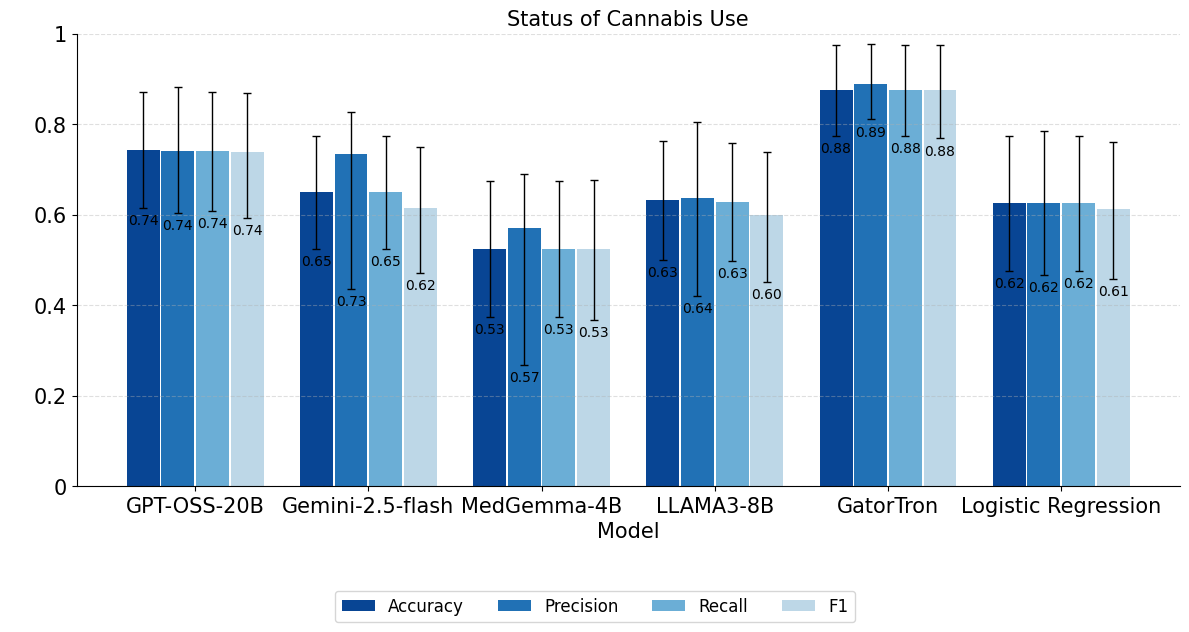

Saved high-resolution confusion matrix to output/model_performance_comparison/figures/status_gatortron_confusion_matrix.png


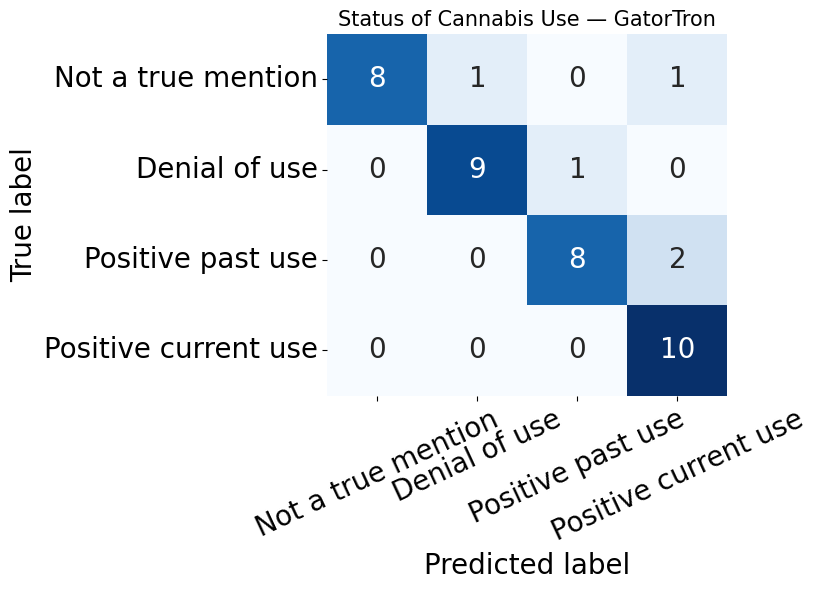

In [20]:
# ── Status classification ────────────────────────────────────────────────────
status_point, status_err_lower, status_err_upper, status_best_runs = build_comparison_tables(
    STATUS_MODEL_PATHS,
    task="status",
)
print("Status best-run metrics loaded:")
print(status_point.round(3))

plot_model_comparison(
    status_point,
    status_err_lower,
    status_err_upper,
    title="Status of Cannabis Use",
    save_path=os.path.join(FIGURE_DIR, "status_model_performance_comparison.png"),
)

plot_best_confusion_matrix(
    status_best_runs["GatorTron"],
    title="Status of Cannabis Use — GatorTron",
    class_labels=[0, 1, 2, 3],
    label_names=["Not a true mention", "Denial of use", "Positive past use", "Positive current use"],
    save_path=os.path.join(FIGURE_DIR, "status_gatortron_confusion_matrix.png"),
)

### Reason classification

reason | GPT-OSS-20B: predictions_two_shot_temp_0.3.csv (model=gpt-oss-20b, strategy=two_shot, temperature=0.3)
reason | Gemini-2.5-flash: output_reason_prompting_test_v2_gemini-2-5-flash_prediction_predictions_one_shot_temp0.3.csv (model=gemini-2.5-flash, strategy=one_shot, temperature=0.3)
reason | MedGemma-4B: predictions_multi_step_verification_temp_1.0.csv (model=medgemma-4b-it, strategy=multi_step_verification, temperature=1.0)
reason | LLAMA3-8B: predictions_structured_reasoning_temp_0.0.csv (model=Llama-3.1-8B-Instruct, strategy=structured_reasoning, temperature=0.0)
reason | GatorTron: best_test_predictions_bootstrap.csv
reason | Logistic Regression: best_test_predictions.csv

Reason best-run metrics loaded:
                     Accuracy  Precision  Recall     F1
GPT-OSS-20B              0.84      0.860    0.84  0.834
Gemini-2.5-flash         0.80      0.832    0.80  0.801
MedGemma-4B              0.52      0.462    0.52  0.473
LLAMA3-8B                0.78      0.812    0.78 

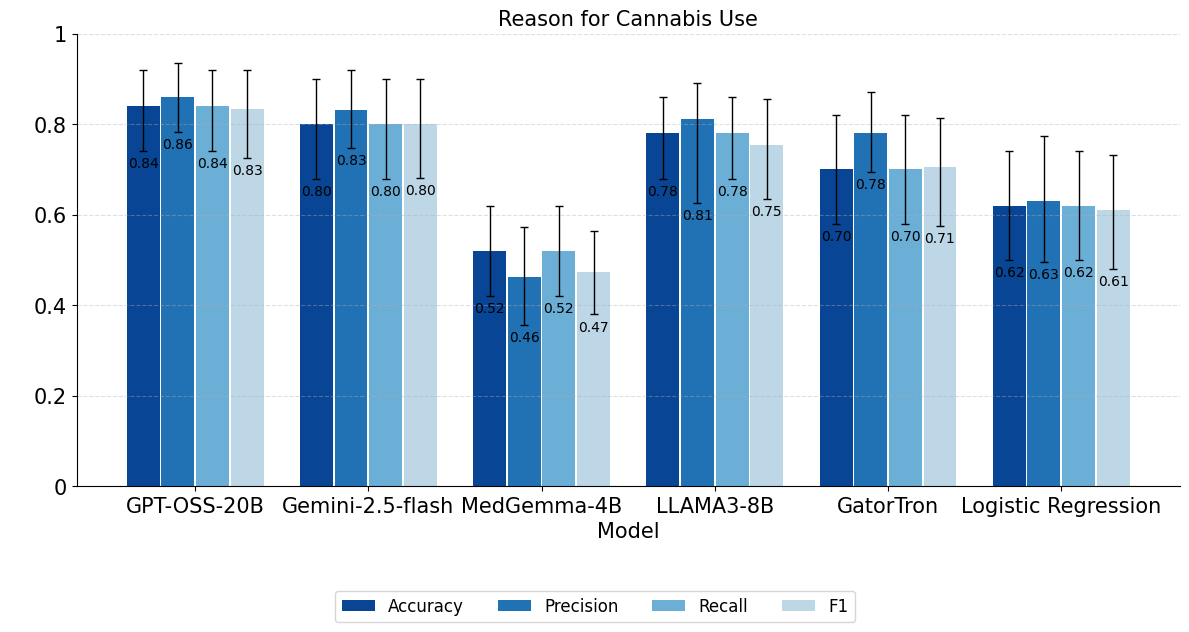

Saved high-resolution confusion matrix to output/model_performance_comparison/figures/reason_gpt_oss_20b_confusion_matrix.png


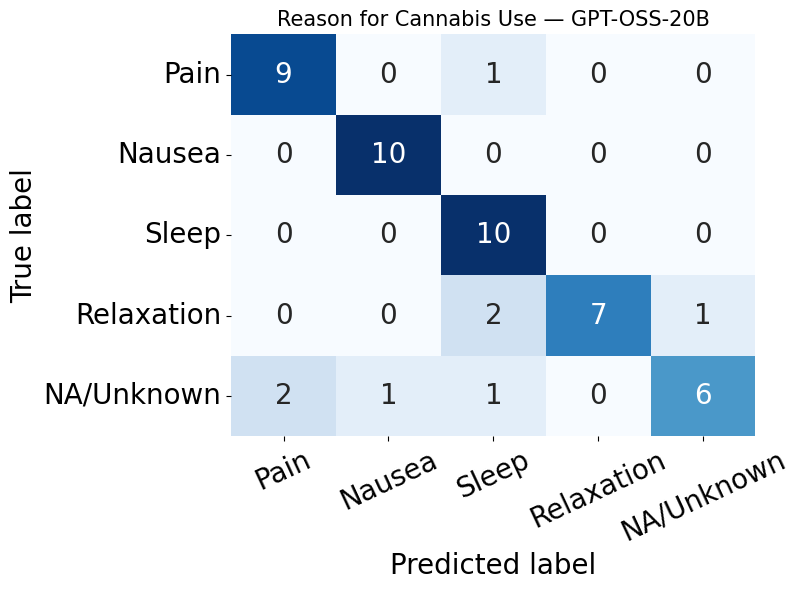

In [21]:
# ── Reason classification ──────────────────────────────────────────────────
reason_point, reason_err_lower, reason_err_upper, reason_best_runs = build_comparison_tables(
    REASON_MODEL_PATHS,
    task="reason",
)
print("\nReason best-run metrics loaded:")
print(reason_point.round(3))

plot_model_comparison(
    reason_point,
    reason_err_lower,
    reason_err_upper,
    title="Reason for Cannabis Use",
    save_path=os.path.join(FIGURE_DIR, "reason_model_performance_comparison.png"),
)

plot_best_confusion_matrix(
    reason_best_runs["GPT-OSS-20B"],
    title="Reason for Cannabis Use — GPT-OSS-20B",
    class_labels=[ 1, 2, 3, 4,5],
    label_names=["Pain", "Nausea", "Sleep", "Relaxation", "NA/Unknown"],
    save_path=os.path.join(FIGURE_DIR, "reason_gpt_oss_20b_confusion_matrix.png"),
)

In [22]:
best_run = reason_best_runs["GPT-OSS-20B"]
predictions = best_run["predictions"].dropna(
    subset=["label", "predicted_label"]
)

y_true = predictions["label"].to_numpy()
y_pred = predictions["predicted_label"].to_numpy()
print(classification_report(y_true, y_pred, target_names=["Pain", "Nausea", "Sleep", "Relaxation", "NA/Unknown"], digits=3))

              precision    recall  f1-score   support

        Pain      0.818     0.900     0.857        10
      Nausea      0.909     1.000     0.952        10
       Sleep      0.714     1.000     0.833        10
  Relaxation      1.000     0.700     0.824        10
  NA/Unknown      0.857     0.600     0.706        10

    accuracy                          0.840        50
   macro avg      0.860     0.840     0.834        50
weighted avg      0.860     0.840     0.834        50

